### PART 1: Build a Predictive Model on “employee_attrition_previous_closure.csv”, to predict the probability of an employee leaving after being offered an RCC.

***Step 1:  Data Exploration and Visualization***

In this section, we will load the dataset "employee_attrition_previous_closure.csv", perform initial exploration, and visualize the data to understand its characteristics.

In [40]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Enable inline plotting in Jupyter Notebook
%matplotlib inline

# Set a visual style for the plots
sns.set(style="whitegrid")


In [41]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv("employee_attrition_previous_closure.csv")

# Display the first 5 rows of the dataset to understand its structure
df.head()

# Get the number of rows and columns
print("Dataset Shape:", df.shape)

# Get information on data types and missing values
df.info()

# View basic descriptive statistics for numerical columns
df.describe()


Dataset Shape: (1029, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1029 entries, 0 to 1028
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition                 1029 non-null   object 
 1   Age                       893 non-null    float64
 2   BusinessTravel            1024 non-null   object 
 3   DailyRate                 1002 non-null   float64
 4   Department                1029 non-null   object 
 5   DistanceFromHome          934 non-null    float64
 6   Education                 1029 non-null   int64  
 7   EducationField            1029 non-null   object 
 8   EmployeeCount             1029 non-null   int64  
 9   EmployeeNumber            1029 non-null   int64  
 10  EnvironmentSatisfaction   1029 non-null   int64  
 11  Gender                    1029 non-null   object 
 12  HourlyRate                1029 non-null   int64  
 13  JobInvolvement            1029 non-nu

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,893.000000,1002.000000,934.000000,1029.000000,1029.0,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,...,1029.000000,1029.0,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000
mean,37.930571,800.528942,9.930407,2.892128,1.0,1024.367347,2.683188,66.680272,2.713314,2.043732,...,2.689990,80.0,0.822157,11.196307,2.782313,2.748299,6.942663,4.215743,2.119534,4.005831
std,9.395978,408.109828,8.421791,1.053541,0.0,606.301635,1.096829,20.474094,0.710146,1.118918,...,1.077767,0.0,0.874662,7.857581,1.283401,0.697278,6.068322,3.658595,3.108651,3.522574
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,458.250000,2.000000,2.000000,1.0,496.000000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,37.000000,801.500000,8.000000,3.000000,1.0,1019.000000,3.000000,67.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,44.000000,1162.000000,16.000000,4.000000,1.0,1553.000000,4.000000,84.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,2.000000,7.000000
max,60.000000,1496.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


In [42]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 Attrition                     0
Age                         136
BusinessTravel                5
DailyRate                    27
Department                    0
DistanceFromHome             95
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 5
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLife

Numeric Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


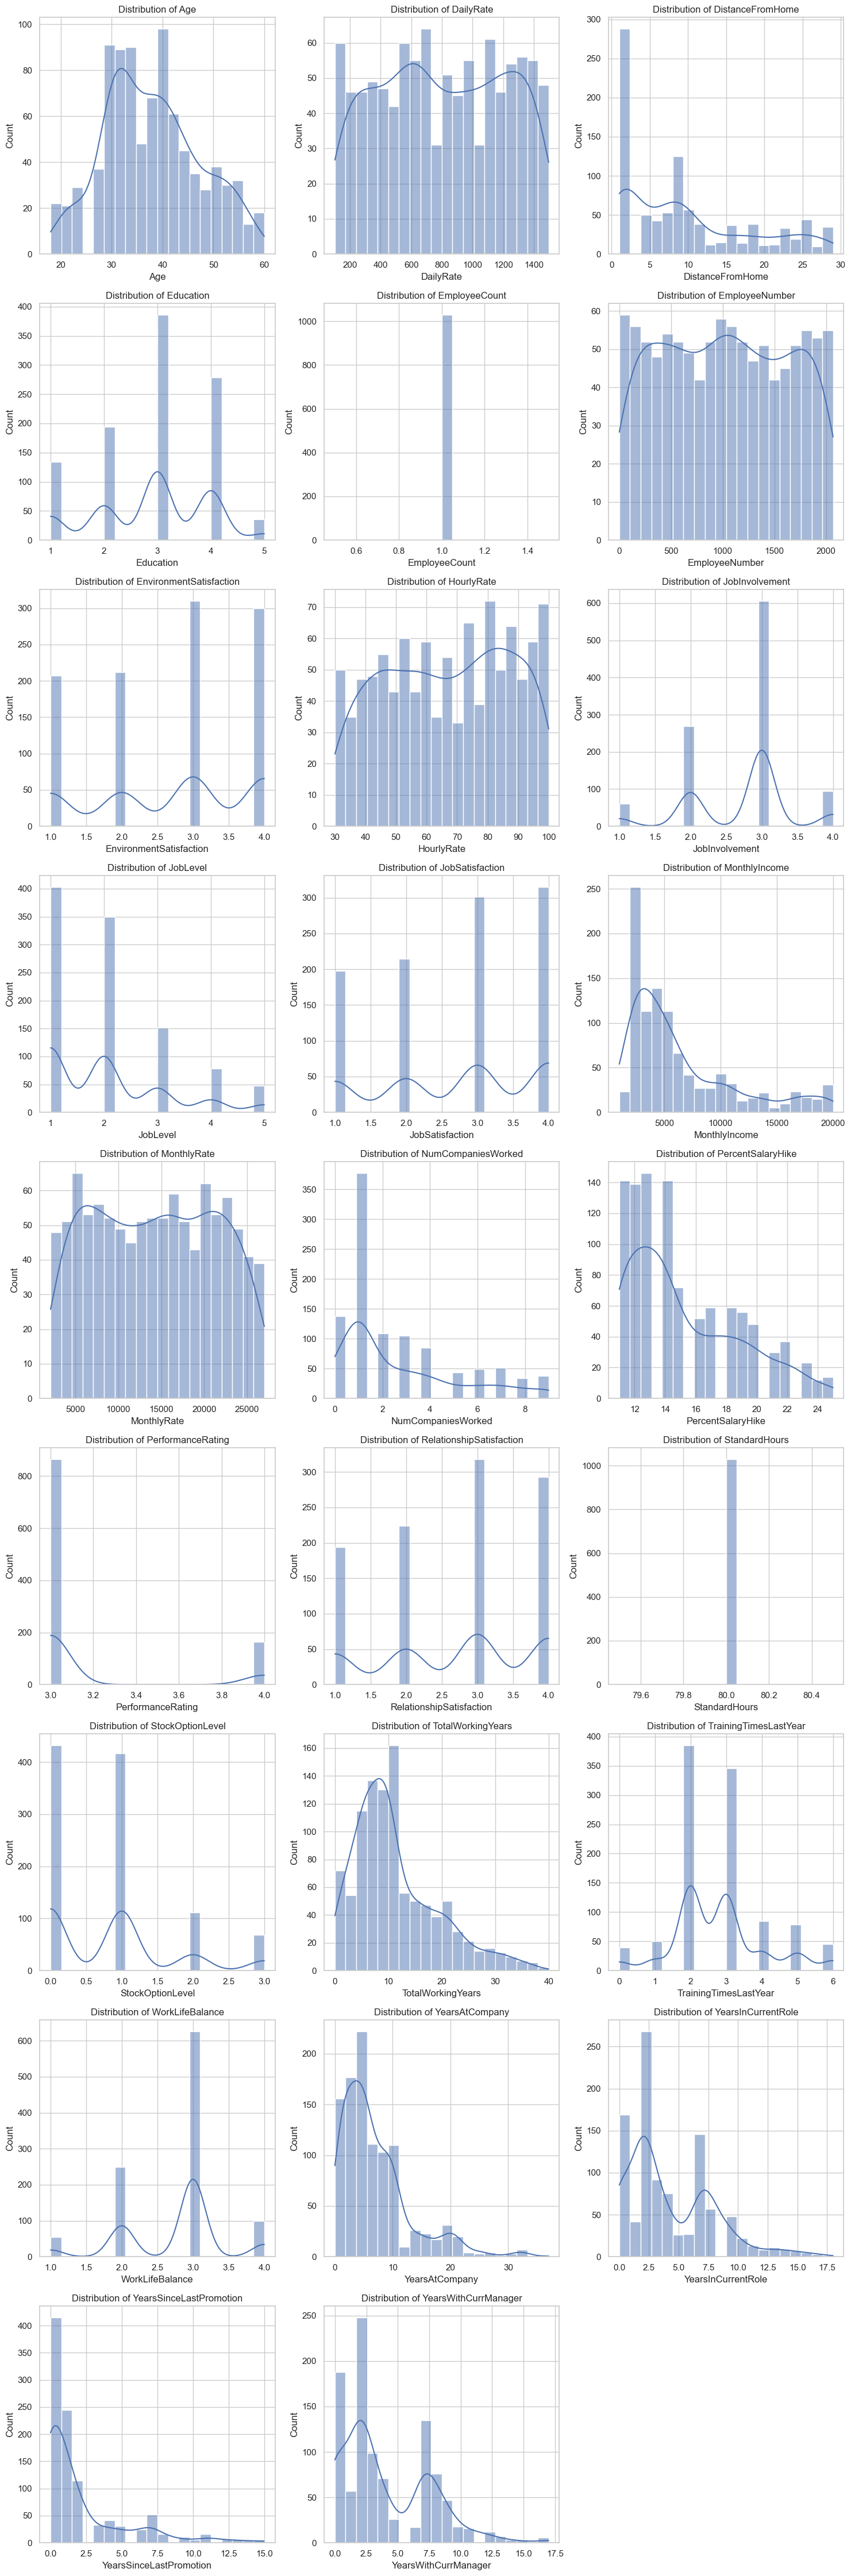

In [43]:
# Plot histograms for all numerical columns

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric Columns:", numeric_cols)

# Set up the matplotlib figure
num_cols = len(numeric_cols)
rows = (num_cols // 3) + (num_cols % 3 > 0)  # Calculate the number of rows needed
plt.figure(figsize=(15, 5 * rows))  # Adjust the figure size dynamically
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 3, i)  # Adjust the grid size dynamically
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

***Tenure & Career Progression***

YearsAtCompany, YearsWithCurrManager, and YearsInCurrentRole are right-skewed — many employees are relatively new, potentially less attached and more likely to accept an RCC.

YearsSinceLastPromotion is mostly 0–2, suggesting limited recent advancement — a possible driver of dissatisfaction and exit.

***Income & Job Level***

MonthlyIncome is skewed with a concentration at lower levels, which may correlate with higher attrition, especially among undervalued employees.

JobLevel clusters around lower levels, pointing to early/mid-career employees who may be more open to leaving for better opportunities.

***Satisfaction & Work-Life***

JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, and WorkLifeBalance all show variation — key indicators of employee well-being and strong predictors of RCC acceptance.

***Career Background***

TotalWorkingYears and NumCompaniesWorked are skewed — less experienced or more mobile employees may be more inclined to leave.

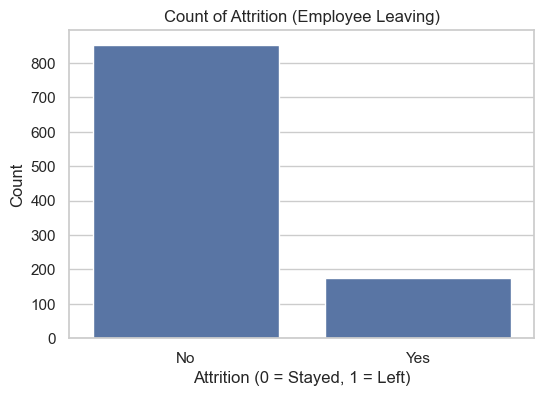

In [44]:
#  Visualizing the Target Variable
# This visualization helps us understand the distribution of the target variable and whether the dataset is balanced or imbalanced.
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Count of Attrition (Employee Leaving)")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Count")
plt.show()

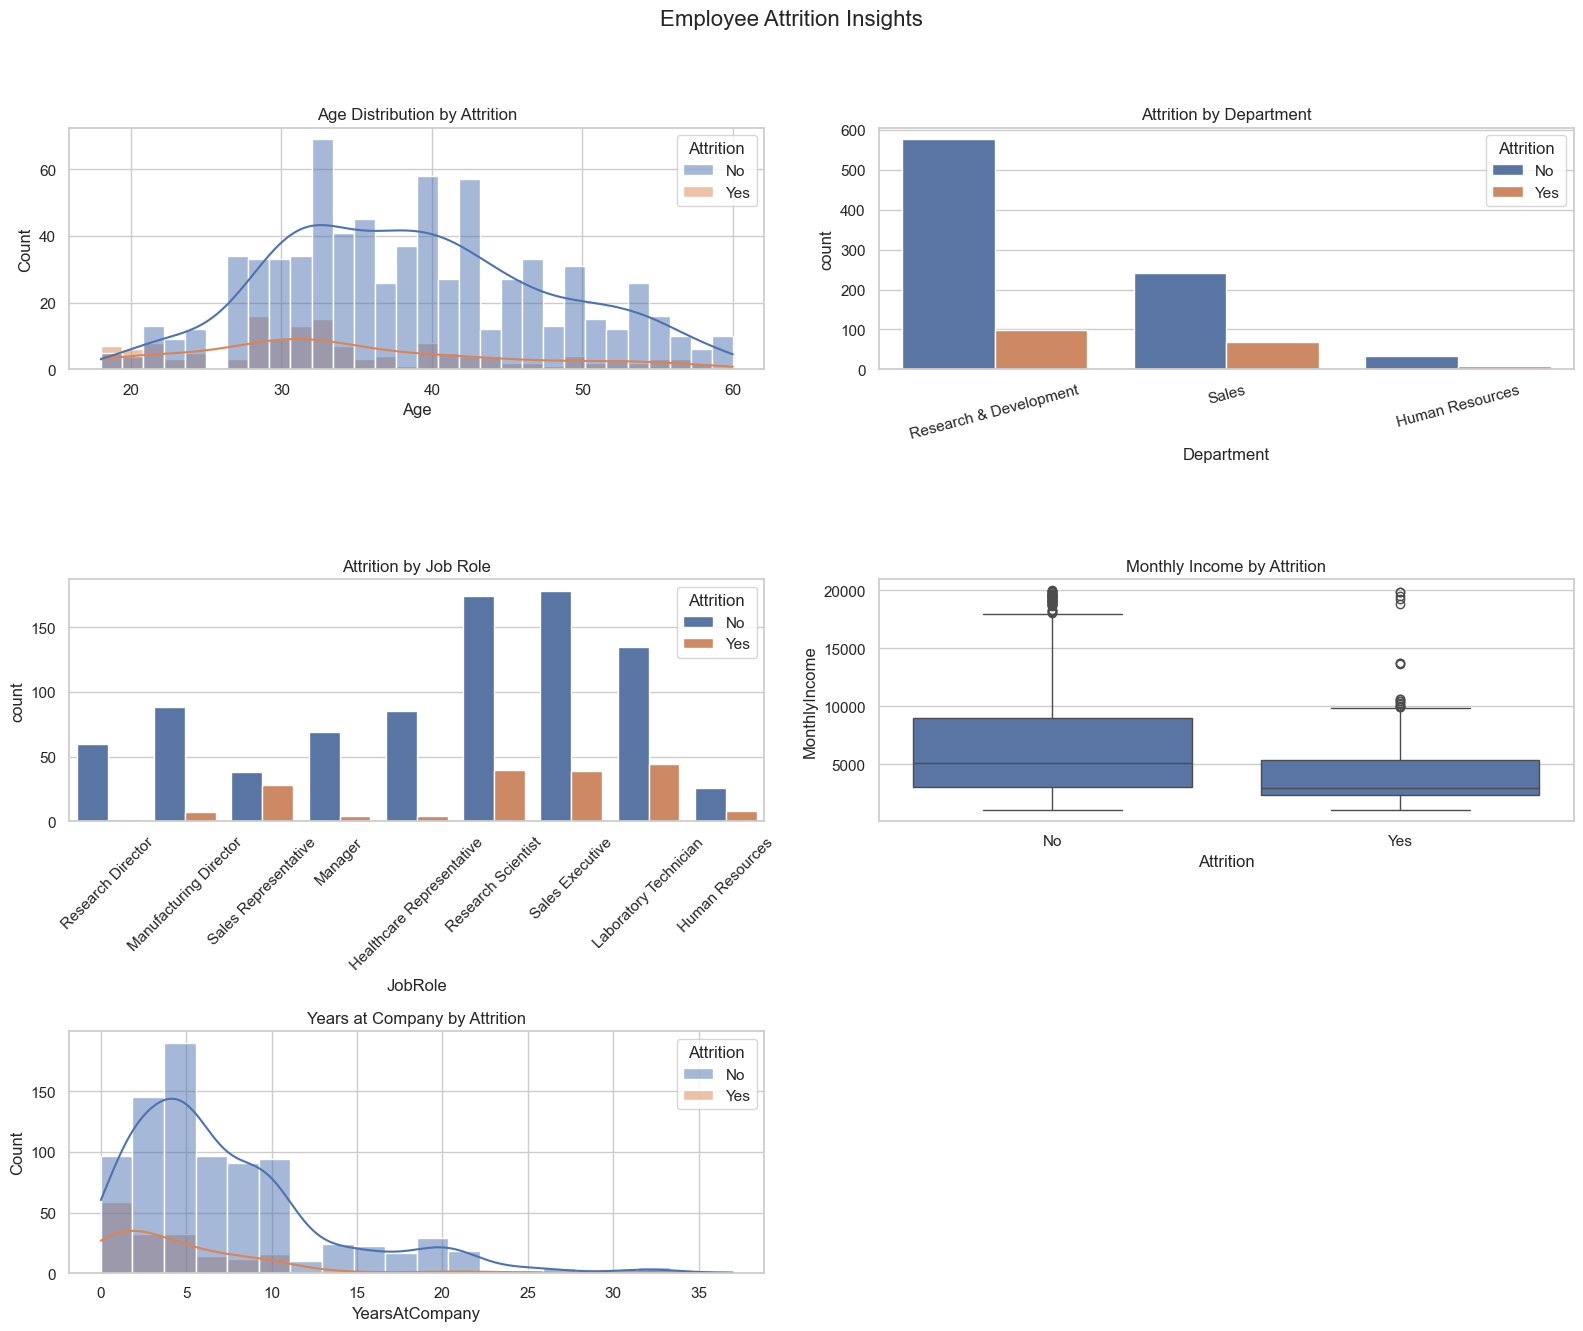

In [45]:
# Visualizing some key features against the target variable
# This section visualizes the relationship between various features and the target variable (Attrition).

# Set up a 3x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Age Distribution
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, bins=30, ax=axs[0, 0])
axs[0, 0].set_title('Age Distribution by Attrition')

# 2. Attrition by Department
sns.countplot(data=df, x='Department', hue='Attrition', ax=axs[0, 1])
axs[0, 1].set_title('Attrition by Department')
axs[0, 1].tick_params(axis='x', rotation=15)

# 3. Job Role vs Attrition
sns.countplot(data=df, x='JobRole', hue='Attrition', ax=axs[1, 0])
axs[1, 0].set_title('Attrition by Job Role')
axs[1, 0].tick_params(axis='x', rotation=45)

# 4. Monthly Income by Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axs[1, 1])
axs[1, 1].set_title('Monthly Income by Attrition')

# 5. Years at Company vs Attrition
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', bins=20, kde=True, ax=axs[2, 0])
axs[2, 0].set_title('Years at Company by Attrition')

# Hide empty subplot (bottom-right)
axs[2, 1].axis('off')

plt.suptitle("Employee Attrition Insights", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

***Interpretation***

The plots offer clear patterns in employee behavior regarding attrition. Employees in their late 20s to late 30s were more likely to leave, indicating that younger, mid-career professionals may be more open to change.

Department-wise, while Research & Development had the highest headcount, Sales showed a higher relative attrition, suggesting more job mobility or pressure in those roles. Within job roles, attrition was more frequent among Sales Executives and Research Scientists, possibly due to transferable skills and external opportunities.

The income boxplot revealed that those who left generally had lower monthly incomes, suggesting that financial dissatisfaction might be a driver. Finally, employees with fewer years at the company showed higher attrition, indicating lower attachment among newer staff.

These trends help shape our understanding of which profiles are more likely to accept an RCC, guiding our prediction model accordingly.



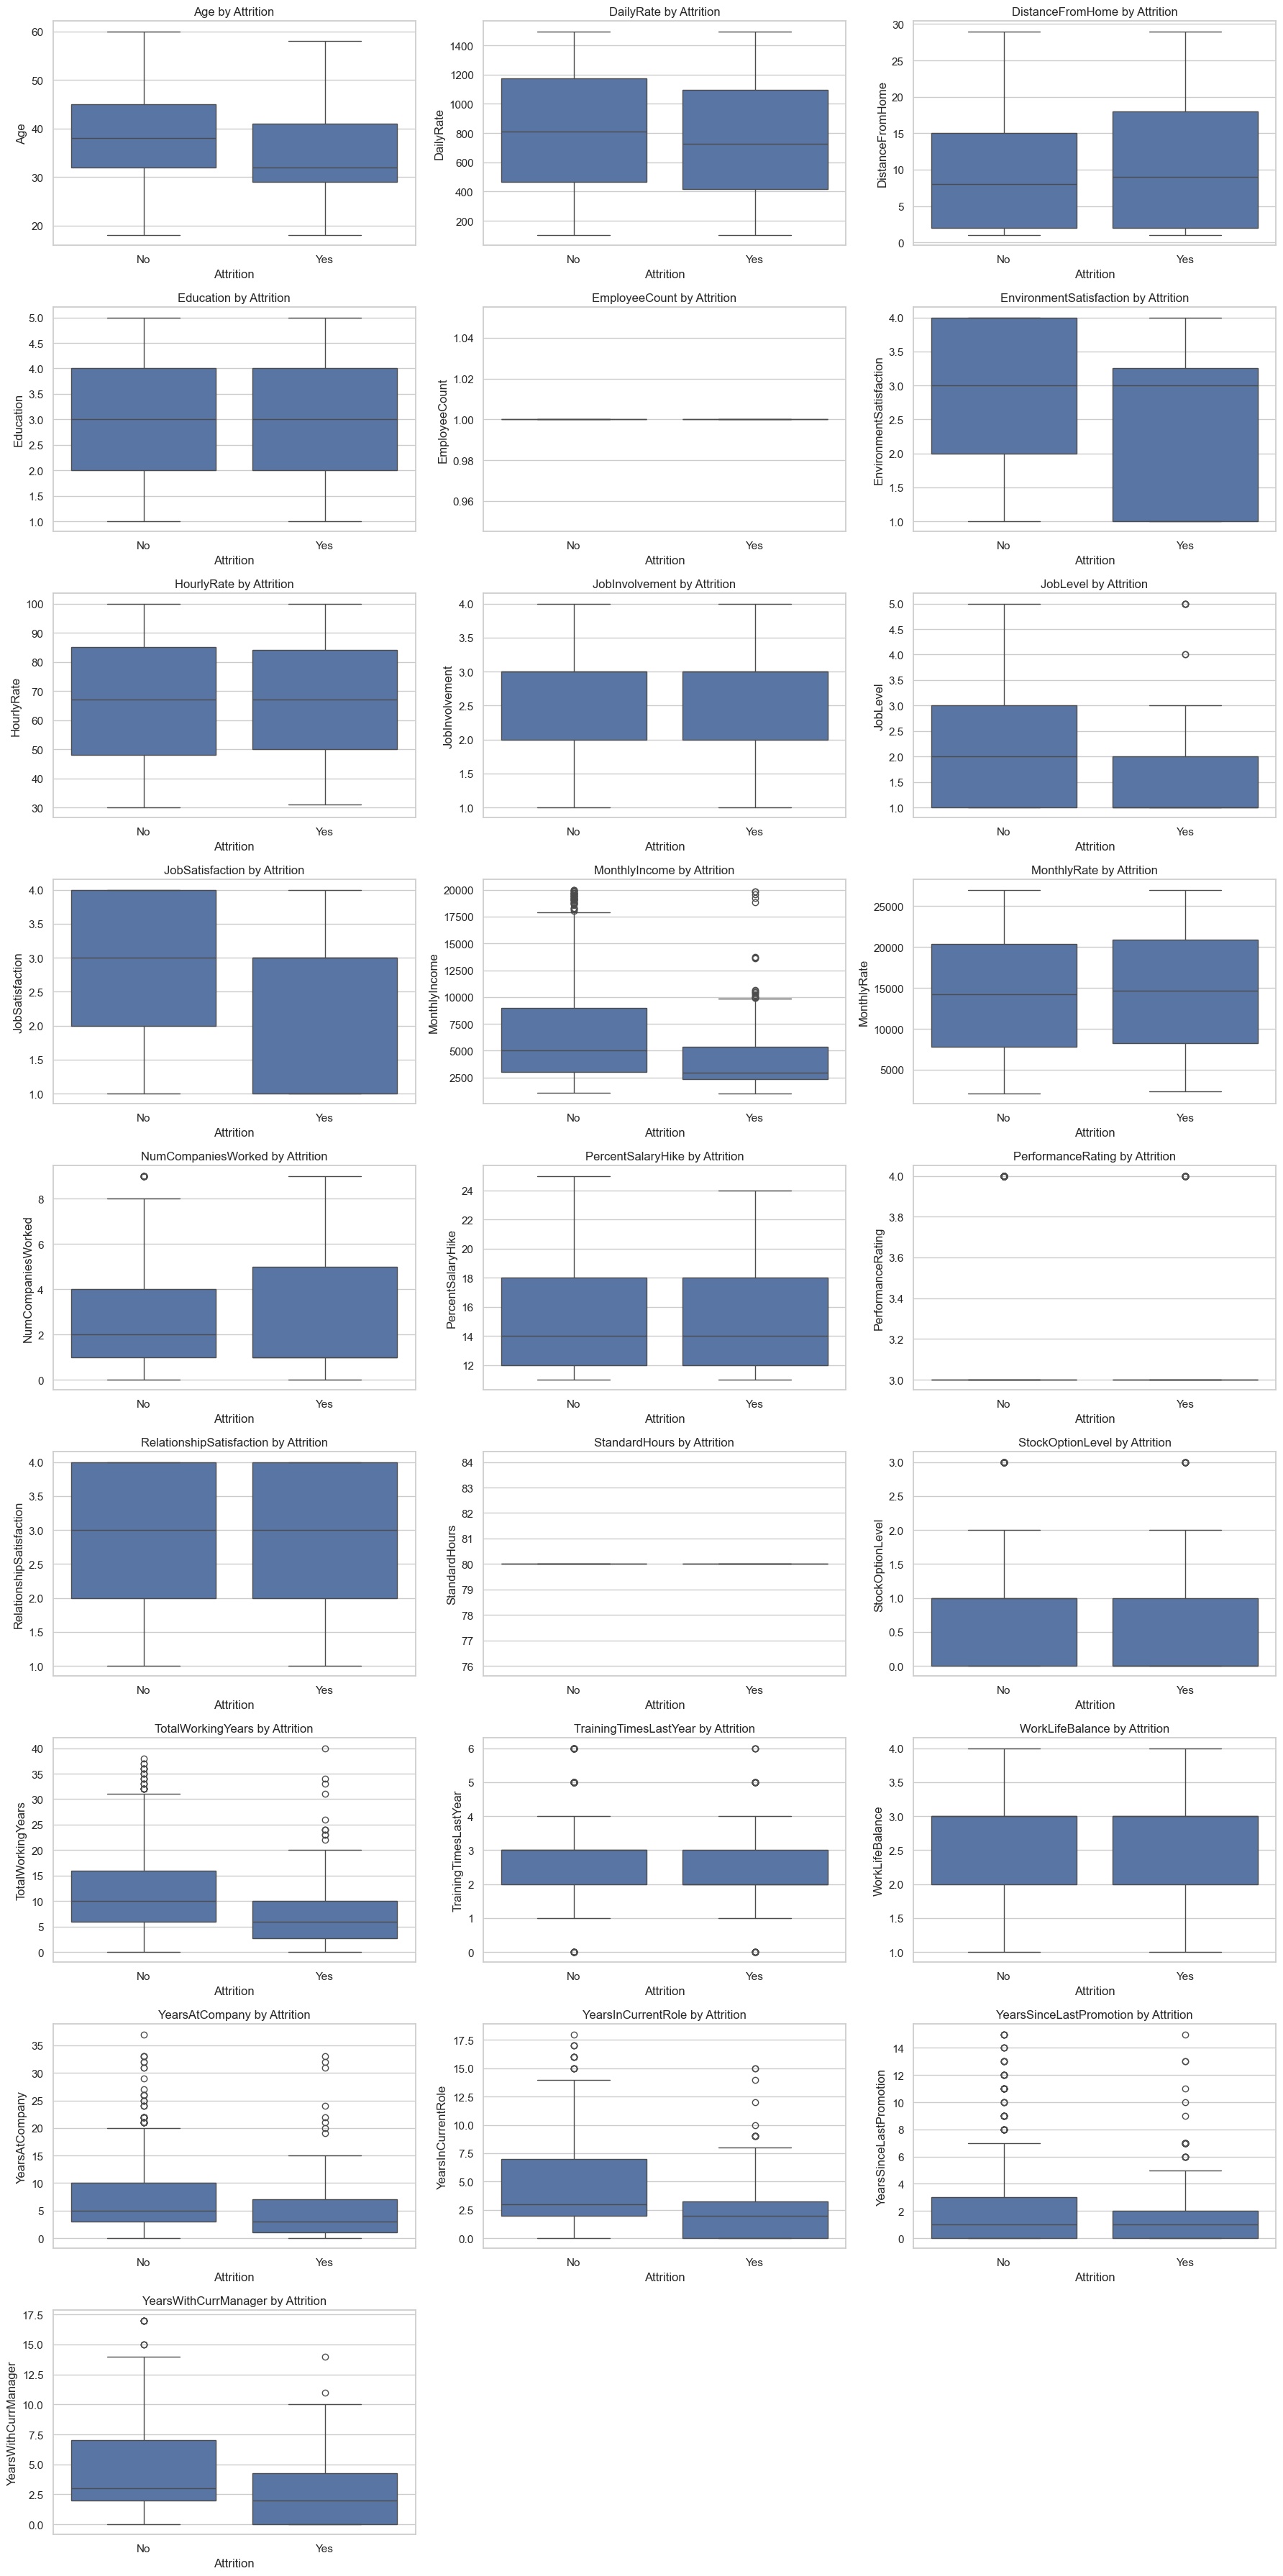

In [46]:
# Visualizing outliers in numerical features against the target variable

# Convert Attrition to binary if needed for correlation or plotting
df_plot = df.copy()
df_plot['Attrition'] = df_plot['Attrition'].astype(str)

# Identify numerical features
num_features = df_plot.select_dtypes(include=['int64', 'float64']).columns
num_features = [col for col in num_features if col != 'EmployeeNumber']  # optional exclusion

# Plotting
n_cols = 3
n_rows = int(np.ceil(len(num_features) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, feature in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df_plot, x='Attrition', y=feature)
    plt.title(f'{feature} by Attrition')

plt.tight_layout()
plt.show()


***Interpretation***

The boxplots reveal clear differences between employees who stayed and those who left, helping us identify strong predictors for RCC acceptance.

Employees who left were generally younger, had fewer years at the company, and had spent less time in their current roles or with their managers. They also had fewer promotions, as shown by lower values in YearsSinceLastPromotion.

Financially, those who left earned lower monthly incomes and were in lower job levels, indicating that income and seniority are important factors. They also had less total work experience, suggesting newer professionals are more likely to exit.

Satisfaction metrics like JobSatisfaction and EnvironmentSatisfaction were visibly lower among those who left, making them strong indicators of attrition risk.

On the other hand, variables like PerformanceRating, EmployeeCount, StandardHours, and TrainingTimesLastYear showed little to no variation and can be deprioritized during modeling.

Overall, lower satisfaction, lower income, and shorter tenure emerge as the strongest signals of voluntary attrition.

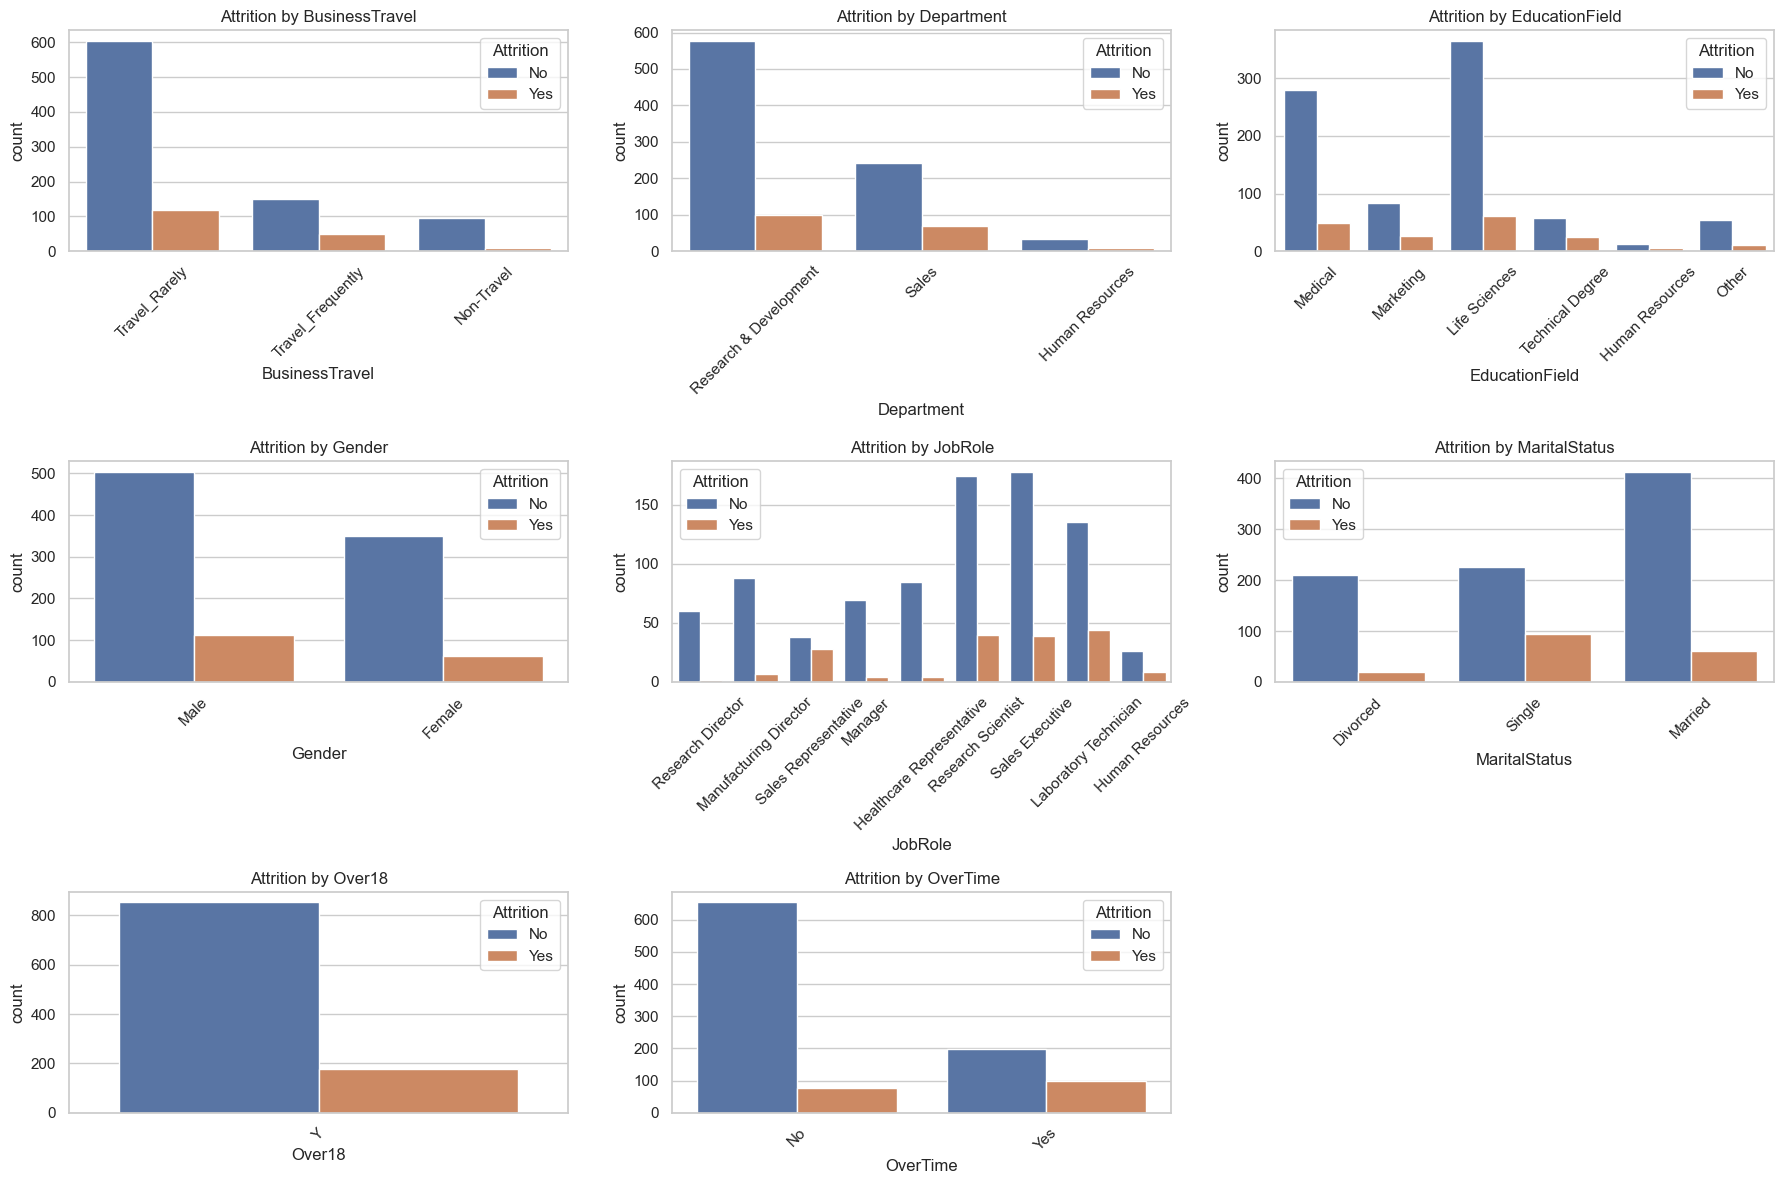

In [47]:
# Identify categorical features
cat_features = df_plot.select_dtypes(include='object').columns
cat_features = [col for col in cat_features if col != 'Attrition']

# Plotting
n_cols = 3
n_rows = int(np.ceil(len(cat_features) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, feature in enumerate(cat_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df_plot, x=feature, hue='Attrition')
    plt.title(f'Attrition by {feature}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

***Interpretation***

Some categorical variables show strong links with attrition and offer valuable input for prediction.

Employees who work overtime are clearly more likely to leave, making OverTime one of the strongest indicators. Similarly, those with frequent business travel show higher attrition, suggesting that job-related strain impacts voluntary exits.

JobRole also plays a key role — attrition is higher among Sales Representatives and Laboratory Technicians, while Research Scientists tend to stay. This highlights role-specific turnover trends.

MaritalStatus shows that single and divorced employees are more likely to leave than married ones, possibly reflecting different risk preferences or life stability. Likewise, attrition is proportionally higher in the Sales department, indicating department-specific dynamics.

In contrast, features like Gender and EducationField show only mild variation, and Over18 is constant and non-informative.

Overall, OverTime, JobRole, BusinessTravel, and MaritalStatus stand out as strong predictors of attrition and are key to building a robust model.

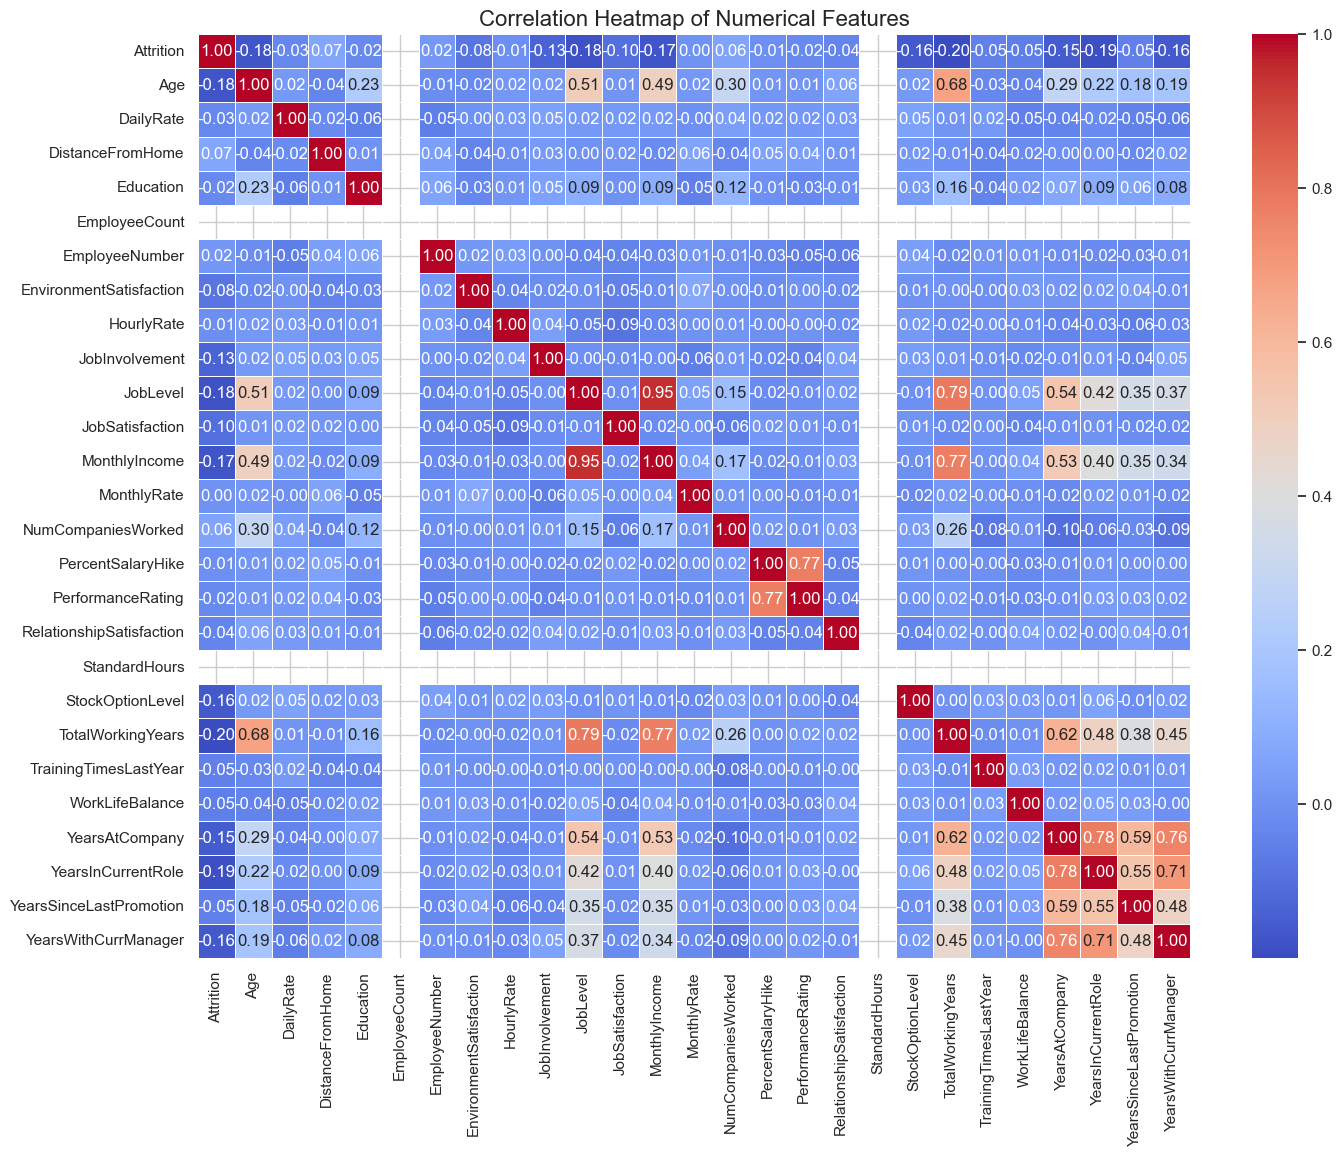

In [48]:
# Make a copy and encode Attrition
df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})

# Select only numerical columns
numerical_cols = df_corr.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr_matrix = df_corr[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

***Step 2: Data Cleaning and Preprocessing***

In this section, we will clean the dataset by removing unnecessary columns, handling missing values, and encoding categorical variables. We will also split the data into training and testing sets.

**2.1: Handling missing values in numerical and categorical features**

In [49]:
# Handling missing values in the numerical columns
# Fill missing values with the median for numerical columns becsause median is more robust than mean to outliers and can handle extreme values better.
# Make a copy of the DataFrame to avoid modifying the original one
df_cleaned = df.copy()
df_cleaned['Age'].fillna(df_cleaned['Age'].median(), inplace=True)
df_cleaned['DailyRate'].fillna(df_cleaned['DailyRate'].median(), inplace=True)
df_cleaned['DistanceFromHome'].fillna(df_cleaned['DistanceFromHome'].median(), inplace=True)

# Handling missing values in categorical columns
# Fill missing values with the mode for categorical columns because mode is the most frequent value and can be a good representation of the data.
# Fill categorical columns with mode
df_cleaned['BusinessTravel'].fillna(df_cleaned['BusinessTravel'].mode()[0], inplace=True)
df_cleaned['MaritalStatus'].fillna(df_cleaned['MaritalStatus'].mode()[0], inplace=True)

# Display the cleaned DataFrame to verify that missing values have been handled
print("Missing Values After Cleaning:\n", df_cleaned.isnull().sum())
# Check the cleaned DataFrame
df_cleaned.head()

Missing Values After Cleaning:
 Attrition                   0
Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

C:\Users\Tithi\AppData\Local\Temp\ipykernel_29312\1266907295.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['Age'].fillna(df_cleaned['Age'].median(), inplace=True)
C:\Users\Tithi\AppData\Local\Temp\ipykernel_29312\1266907295.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,No,50.0,Travel_Rarely,1126.0,Research & Development,1.0,2,Medical,1,997,...,3,80,1,32,1,2,5,4,1,3
1,No,36.0,Travel_Rarely,216.0,Research & Development,6.0,2,Medical,1,178,...,4,80,2,7,0,3,3,2,0,1
2,Yes,21.0,Travel_Rarely,337.0,Sales,7.0,1,Marketing,1,1780,...,2,80,0,1,3,3,1,0,1,0
3,No,50.0,Travel_Frequently,1246.0,Human Resources,8.0,3,Medical,1,644,...,3,80,1,32,2,3,32,5,10,7
4,No,52.0,Travel_Rarely,994.0,Research & Development,7.0,4,Life Sciences,1,1118,...,4,80,0,18,4,3,8,6,4,0


**2.2: Dropping non-informative features and constant features**

In [50]:
# Let's drop non-informative and constant columns like EmployeeNumber, EmployeeCount, StandardHours, Over18, and PerformanceRating
# But before dropping, let's check the unique values in these columns to understand their content
print("Unique values in EmployeeCount:", df_cleaned['EmployeeCount'].unique())
print("Unique values in StandardHours:", df_cleaned['StandardHours'].unique())
print("Unique values in Over18:", df_cleaned['Over18'].unique())
print("Unique values in PerformanceRating:", df_cleaned['PerformanceRating'].unique())

# Print the features with constant values
constant_cols = [col for col in df_cleaned.columns if df_cleaned[col].nunique() == 1]
print("Constant columns:", constant_cols)

# Drop the identified columns
df_cleaned.drop(columns=[
    'EmployeeNumber', 
    'EmployeeCount', 
    'Over18', 
    'StandardHours', 
], inplace=True)

# Display the cleaned DataFrame to verify that the columns have been dropped
print("DataFrame Shape After Dropping Columns:", df_cleaned.shape)

Unique values in EmployeeCount: [1]
Unique values in StandardHours: [80]
Unique values in Over18: ['Y']
Unique values in PerformanceRating: [4 3]
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
DataFrame Shape After Dropping Columns: (1029, 31)


**2.3: Using One-Hot Encoding for categorical features**

In [51]:
# Convert the target 'Attrition' to numeric (Yes → 1, No → 0)
df_cleaned['Attrition'] = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})

# Convert categorical variables to numerical using one-hot encoding
# Because it's safe for both binary and nominal variables, avoids assuming any ordinal relationship between categories.
# Works well for tree-based models and linear models.

# Exclude 'Attrition' during one-hot encoding
df_encoded = pd.get_dummies(df_cleaned.drop('Attrition', axis=1), drop_first=True)

# Reattach the target column to the encoded DataFrame
df_encoded['Attrition'] = df_cleaned['Attrition']

# Display the first few rows of the encoded DataFrame to verify the transformation
print("Encoded DataFrame Shape:", df_encoded.shape)
print("Encoded DataFrame Head:\n", df_encoded.head())

# Check the columns that were newly created by one-hot encoding
# This will help us identify which categorical variables were transformed into dummy variables
encoded_cols = df_encoded.columns.difference(df_cleaned.columns)
print("New encoded columns:\n", encoded_cols)

Encoded DataFrame Shape: (1029, 45)
Encoded DataFrame Head:
     Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  50.0     1126.0               1.0          2                        4   
1  36.0      216.0               6.0          2                        2   
2  21.0      337.0               7.0          1                        2   
3  50.0     1246.0               8.0          3                        1   
4  52.0      994.0               7.0          4                        2   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0          66               3         4                4          17399  ...   
1          84               3         2                2           4941  ...   
2          31               3         1                2           2679  ...   
3          99               3         5                2          18200  ...   
4          87               3         3                2          10445  ...   

 

In [52]:
# Since, after one-hot encoding, the new columns are of type bool, we need to convert them to integers (0 and 1) for better compatibility with machine learning algorithms.
# Convert boolean columns to integers (0 and 1)
df_encoded = df_encoded.astype(int)

# Display the first few rows of the DataFrame to verify the conversion
print("DataFrame Head After Conversion:\n", df_encoded.head())
# Check the data types of the columns to ensure they are as expected
print("Data Types of Columns:\n", df_encoded.dtypes)


DataFrame Head After Conversion:
    Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0   50       1126                 1          2                        4   
1   36        216                 6          2                        2   
2   21        337                 7          1                        2   
3   50       1246                 8          3                        1   
4   52        994                 7          4                        2   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0          66               3         4                4          17399  ...   
1          84               3         2                2           4941  ...   
2          31               3         1                2           2679  ...   
3          99               3         5                2          18200  ...   
4          87               3         3                2          10445  ...   

   JobRole_Manager  JobRole_Manufa

**2.4: Let's set the target variable and split the data into training-validation-testing sets**

3-Way-Split:
* 60% for training
* 20% for validation
* 20% for testing

The reason for this split is to ensure that we have enough data for training the model while also having a separate validation set to tune hyperparameters and a test set to evaluate the final model performance. This approach helps in preventing overfitting and ensures that the model generalizes well to unseen data.
Also, since we are trying to implement many diffferent models, and choose the best one, it'll be better to have a validation set to compare the models.

In [53]:
# Define X (features) and y (target)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Import necessary library for splitting the dataset
from sklearn.model_selection import train_test_split

# First split: train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Second split: train and validation (from X_temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)
# Check the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (617, 44)
X_val shape: (206, 44)
X_test shape: (206, 44)
y_train shape: (617,)
y_val shape: (206,)
y_test shape: (206,)


In [54]:
# Check class distribution to assess imbalance
print("Target Distribution (Attrition):")
print(y.value_counts(normalize=True))

Target Distribution (Attrition):
Attrition
0    0.82896
1    0.17104
Name: proportion, dtype: float64


***Why ROC-AUC is Used Instead of Accuracy***

The target variable `Attrition` is imbalanced — only around 17% of employees in the dataset have left the company.

Using **accuracy alone** can be misleading in such cases. For example, a model that always predicts “Stayed” would achieve 84% accuracy, but completely fail to identify employees who actually left.

Instead, we use **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)** as the primary evaluation metric because:

- **ROC-AUC measures the model's ability to rank positives above negatives**, regardless of the classification threshold.
- It evaluates performance across all possible thresholds, not just 0.5.
- It’s more robust and meaningful for imbalanced classification tasks like attrition prediction.

This ensures we are capturing the true predictive power of our model in identifying employees likely to accept an RCC and leave.


**2.5: Outlier Detection and Removal**

The reason for detecting outliers after splitting the data, is to avoid Data Leakage. If we detect outliers on the full dataset, you’re indirectly “peeking” at the validation/test data.
That means our model could overfit to patterns that won’t generalize, defeating the purpose of a proper test set.
Thus, we always want to simulate the real world where the model has never seen test/validation data.



In [55]:
# Use the IQR method to detect outliers in the training set
# Calculate the IQR for each feature
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1
# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify outliers in the training set
outliers = ((X_train < lower_bound) | (X_train > upper_bound)).sum()
# Display the number of outliers for each feature
print("Number of outliers in each feature:\n", outliers[outliers > 0])

Number of outliers in each feature:
 MonthlyIncome                        33
NumCompaniesWorked                   29
PerformanceRating                    94
StockOptionLevel                     38
TotalWorkingYears                    18
TrainingTimesLastYear                93
YearsAtCompany                       38
YearsInCurrentRole                   12
YearsSinceLastPromotion              88
YearsWithCurrManager                  3
BusinessTravel_Travel_Frequently    125
EducationField_Marketing             58
EducationField_Other                 40
EducationField_Technical Degree      52
JobRole_Human Resources              22
JobRole_Laboratory Technician       102
JobRole_Manager                      47
JobRole_Manufacturing Director       49
JobRole_Research Director            44
JobRole_Research Scientist          131
JobRole_Sales Executive             128
JobRole_Sales Representative         39
dtype: int64


*The above list of outliers detected in features are a mix of Numeric/continuous and binary/categorical features.
The binary features are not outliers, they are just category indicators, so its a false alarm.
Since, we are comparing multiple models to choose the best one, let's cap(winsorize) using IQR method the outliers keeping the data size intact and avoid distortion of the data. So, let's cap the outliers in the numeric/continuous features using IQR method.*

In [56]:
# let's cap(winsorize) the outliers to the lower and upper bounds
# Cap the outliers in the training set
# List of continuous numerical features
continuous_features = [ 
    'MonthlyIncome', 'NumCompaniesWorked', 'StockOptionLevel',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Cap outliers in each feature based on IQR
for col in continuous_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply winsorization (capping)
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)

    print(f"Capped outliers in '{col}' | Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f}")

Capped outliers in 'MonthlyIncome' | Lower: -6324.50, Upper: 18103.50
Capped outliers in 'NumCompaniesWorked' | Lower: -3.50, Upper: 8.50
Capped outliers in 'StockOptionLevel' | Lower: -1.50, Upper: 2.50
Capped outliers in 'TotalWorkingYears' | Lower: -9.00, Upper: 31.00
Capped outliers in 'TrainingTimesLastYear' | Lower: 0.50, Upper: 4.50
Capped outliers in 'YearsAtCompany' | Lower: -8.50, Upper: 19.50
Capped outliers in 'YearsInCurrentRole' | Lower: -5.50, Upper: 14.50
Capped outliers in 'YearsSinceLastPromotion' | Lower: -3.00, Upper: 5.00
Capped outliers in 'YearsWithCurrManager' | Lower: -8.00, Upper: 16.00


***Check if the outliers are capped/winsorized properly***

In [57]:
# Check if outliers are still present after capping
# After applying IQR-based winsorization to continuous features, we re-ran the outlier detection logic and found that no values fall outside the acceptable range. 
# This confirms that outliers were successfully capped without reducing dataset size.

for col in continuous_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_remaining = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"Outliers still in '{col}': {outliers_remaining}")

Outliers still in 'MonthlyIncome': 0
Outliers still in 'NumCompaniesWorked': 0
Outliers still in 'StockOptionLevel': 0
Outliers still in 'TotalWorkingYears': 0
Outliers still in 'TrainingTimesLastYear': 0
Outliers still in 'YearsAtCompany': 0
Outliers still in 'YearsInCurrentRole': 0
Outliers still in 'YearsSinceLastPromotion': 0
Outliers still in 'YearsWithCurrManager': 0


***Step 3: Trying out different models using pipeline***

In this section, we will try out different models using a pipeline. The pipeline will include preprocessing steps such as scaling followed by the model itself. We will use a variety of models to see which one performs best on the validation set.
The models we will try include:
* Logistic Regression
* Support Vector Classifier (SVC)
* Decision Tree Classifier
* Random Forest Classifier
* XGBoost Classifier



**3.1: Let's build a pipeline for the models. The pipeline will include scaling and the model itself.**

We are going to prepare scaled and unscaled datasets. Because the tree based models do not require scaling, we will use the unscaled dataset for them. The scaled dataset will be used for the other models.

In [58]:
from sklearn.preprocessing import StandardScaler

# Scale only numeric features for scaling-sensitive models
# X_train, X_val, X_test → for tree-based models
# X_train_scaled, X_val_scaled, X_test_scaled → for linear/distance-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Check the first few rows of the scaled data
print("Scaled X_train:\n", X_train_scaled[:5])
print("Scaled X_val:\n", X_val_scaled[:5])  
print("Scaled X_test:\n", X_test_scaled[:5])
# Check the shapes of the scaled datasets
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaled X_train:
 [[ 1.54104826e+00 -5.45285856e-01  2.32393707e+00  1.06446019e+00
  -1.49663586e+00 -1.30853198e+00  4.13252935e-01 -9.49902272e-01
   1.15139136e+00 -6.46830622e-01  8.07837654e-01 -2.89169686e-01
  -5.02762903e-02 -4.23948480e-01 -6.54326978e-01  1.55130123e+00
   5.62551143e-01  3.36385167e-01 -1.11318530e+00  4.69014354e-01
   1.05317257e+00 -8.58178259e-01 -1.09956644e+00 -5.04048649e-01
  -1.47108890e+00 -1.38216401e+00  1.53403418e+00  1.17178365e+00
  -3.22112881e-01 -6.79768569e-01 -2.63294683e-01 -3.03373364e-01
   7.70918443e-01 -1.92288299e-01 -4.45037361e-01 -2.87151772e-01
  -2.93713475e-01 -2.77107977e-01 -5.19179473e-01 -5.11623584e-01
   3.84974192e+00 -9.47872111e-01 -6.56928097e-01 -6.29227782e-01]
 [-1.06070535e-01 -4.03024066e-01 -1.11253788e+00  1.00037374e-01
   1.20606948e+00  8.49933580e-01  4.13252935e-01 -9.49902272e-01
  -1.54295176e+00 -9.35546413e-01 -1.32079263e+00 -2.89169686e-01
  -1.13871387e+00 -4.23948480e-01 -6.54326978e-01 -1.00110

*Next, we will create 2 types of models:*
* *Tree based models (Decision Tree, Random Forest, XGBoost)*
* *Non-tree based models (Logistic Regression, SVC)*
* *We will use the unscaled dataset for the tree based models and the scaled dataset for the non-tree based models.*

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Scaled models
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

# Unscaled models
dt_pipeline = Pipeline([
    ('dt', DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])


In [60]:
# Create a dictionary to hold all the models
# This allows for easy iteration over models for training and evaluation

models = {
    'Logistic Regression': logreg_pipeline,
    'SVM': svm_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline
}


d:\Bayes_Software_Setups\Anaconda_Setup\envs\dtvc_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:34:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.830097  0.799165
1                  SVM  0.830097  0.771763
3        Random Forest  0.839806  0.770510
4              XGBoost  0.839806  0.764912
2        Decision Tree  0.771845  0.555806


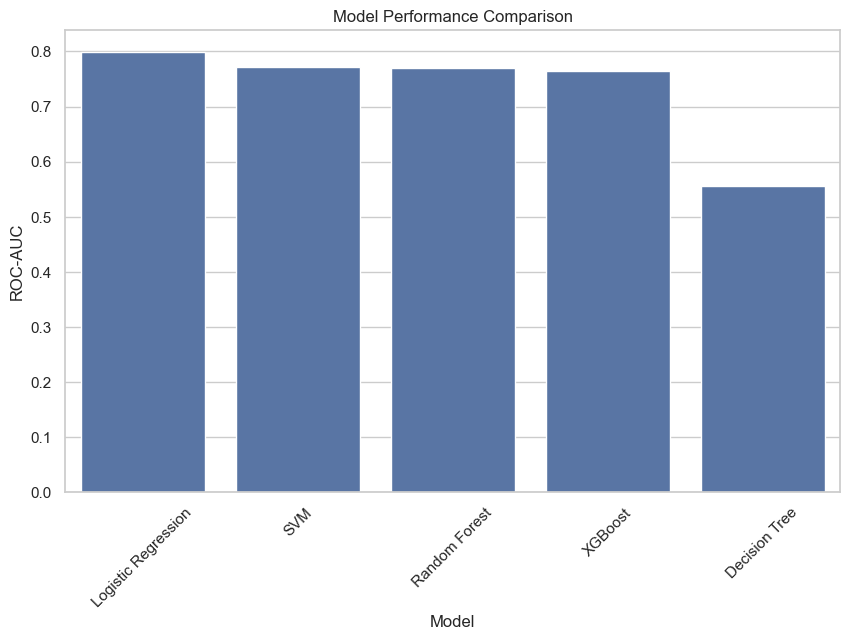

Best Model: Logistic Regression


In [61]:
from sklearn.metrics import accuracy_score, roc_auc_score

results = []

for name, model in models.items():
    # Choose scaled or unscaled X based on model type
    if name in ['Logistic Regression', 'Polynomial Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
    
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'ROC-AUC': auc
    })

# Display results
import pandas as pd
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print(results_df)
# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='ROC-AUC')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.show()
# Final model selection based on ROC-AUC score
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

*To find the best model out of 6 models, we are comparing AUC-ROC and accuracy scores of the models on the validation set.*

***Best Model Selection***
- Logistic Regression is your best model — it balances accuracy and AUC very well. It’s interpretable, stable, and reliable — great for a business-facing assignment!

- Random Forest and SVM also performed well — they could be used as backup or ensemble components.

- XGBoost did slightly worse than expected — might benefit from hyperparameter tuning.

- Polynomial Regression adds complexity but didn’t improve generalization.

- Decision Tree struggled — possibly due to lack of pruning/tuning.

***3.2: Best Model Evaluation***

In this section, we will evaluate the best model (Logistic Regression and Support Vector Classifier) on the test set. We will use the AUC-ROC score and accuracy score to evaluate the model performance. We will also plot the ROC curve and confusion matrix for better visualization.

***3.2.1: Logistic Regression***

*Logistic Regression is a great choice for interpretability and performance. It’s simple yet effective for binary classification tasks like this one. Let’s evaluate it on the test set!*

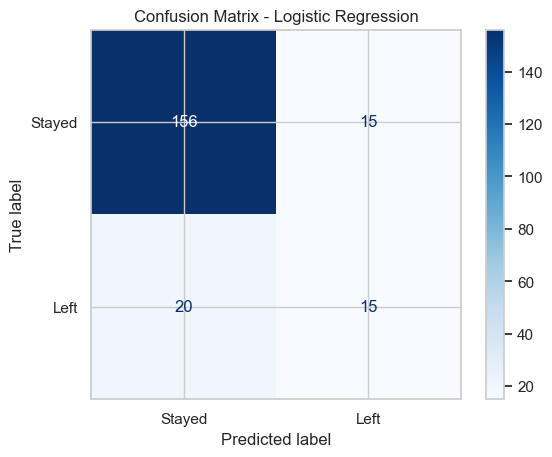


Classification Report - Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.89      0.91      0.90       171
        Left       0.50      0.43      0.46        35

    accuracy                           0.83       206
   macro avg       0.69      0.67      0.68       206
weighted avg       0.82      0.83      0.82       206



In [62]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Let's check the best model's performance on the validation set
# Use correct input based on model type (scaled or unscaled)
if best_model_name in ['Logistic Regression', 'Polynomial Regression', 'SVM']:
    y_val_pred = best_model.predict(X_val_scaled)
else:
    y_val_pred = best_model.predict(X_val)

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# Classification Report
print(f"\nClassification Report - {best_model_name}")
print(classification_report(y_val, y_val_pred, target_names=['Stayed', 'Left']))


*We will use the Logistic Regression model, as it is the best performing model on the validation set. Let's use SMOTE to balance the dataset on training set and then perform GridSearchCV to find the best hyperparameters for the model. We will use the test set to evaluate the model performance.*

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'logreg__C': 10, 'logreg__class_weight': None}
Best CV ROC-AUC Score: 0.9462960474500101
              precision    recall  f1-score   support

      Stayed       0.90      0.82      0.86       171
        Left       0.40      0.57      0.47        35

    accuracy                           0.78       206
   macro avg       0.65      0.70      0.67       206
weighted avg       0.82      0.78      0.80       206



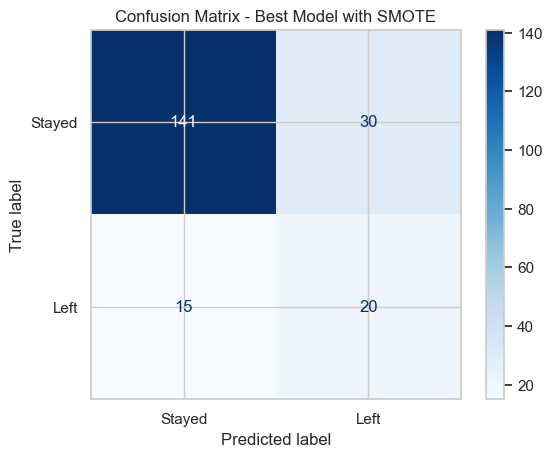

In [63]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1: Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Step 2: Scale SMOTE data
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Step 3: Define pipeline explicitly for GridSearchCV
pipeline = Pipeline([
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Step 4: Set parameter grid
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__class_weight': [None, 'balanced']
}

# Step 5: Perform GridSearchCV on SMOTE-balanced data
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_smote_scaled, y_train_smote)  # Use SMOTE balanced dataset 

# Display best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC Score:", grid_search.best_score_)

# Step 6: Evaluate on validation set using best model
best_model_smote = grid_search.best_estimator_
y_val_proba = best_model_smote.predict_proba(X_val_scaled)[:, 1]

# Adjust threshold to improve recall
threshold = 0.3
y_val_pred_custom = (y_val_proba > threshold).astype(int)

# Evaluate metrics
print(classification_report(y_val, y_val_pred_custom, target_names=['Stayed', 'Left']))
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Best Model with SMOTE")
plt.show()

*Finally, use the best hyperparameters to train the model on the full training+validation set and evaluate on the test set. We will use the AUC-ROC score and accuracy score to evaluate the model performance. We will also plot the ROC curve and confusion matrix for better visualization.*

Class distribution after SMOTE:
 Attrition
0    682
1    682
Name: count, dtype: int64
Final Test Accuracy: 0.7961165048543689
Final Test ROC-AUC: 0.80484544695071

Classification Report (Test Set):
              precision    recall  f1-score   support

      Stayed       0.92      0.82      0.87       171
        Left       0.43      0.66      0.52        35

    accuracy                           0.80       206
   macro avg       0.68      0.74      0.70       206
weighted avg       0.84      0.80      0.81       206



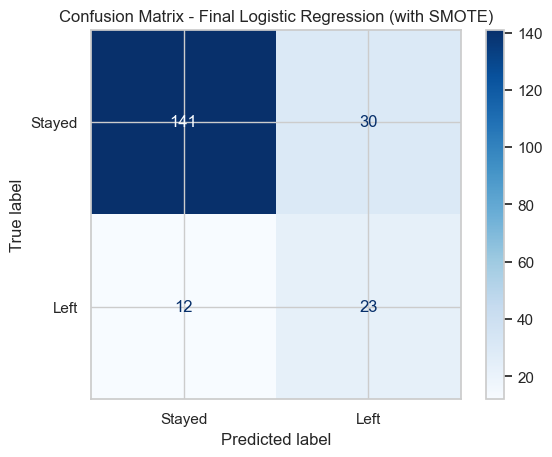

C:\Users\Tithi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


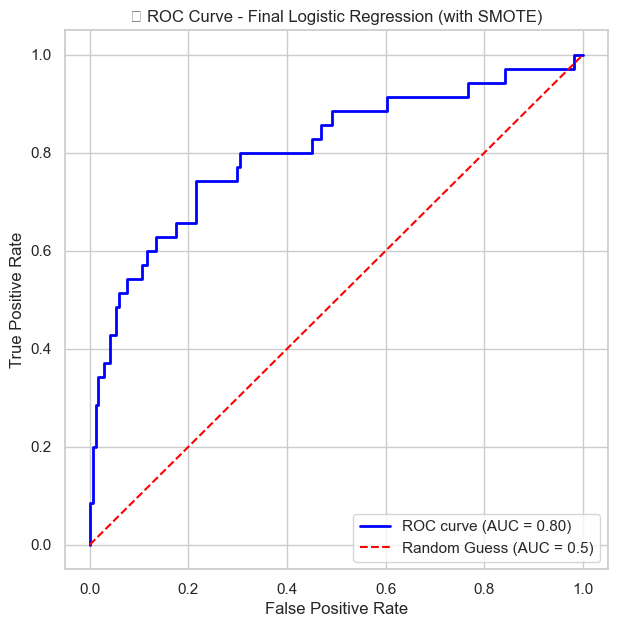

In [64]:
from sklearn.metrics import roc_curve, auc

# --------------------
# Step 1: Prepare Final Dataset (Train + Validation)
# --------------------
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

# --------------------
# Step 2: Apply SMOTE to Final Dataset
# --------------------
smote_final = SMOTE(random_state=42)
X_final_smote, y_final_smote = smote_final.fit_resample(X_final, y_final)

# Verify SMOTE balancing
print("Class distribution after SMOTE:\n", y_final_smote.value_counts())

# --------------------
# Step 3: Scaling the Data (after SMOTE)
# --------------------
scaler_final = StandardScaler()
X_final_smote_scaled = scaler_final.fit_transform(X_final_smote)
X_test_scaled = scaler_final.transform(X_test)

# --------------------
# Step 4: Train Final Logistic Regression Model
# --------------------
# Use best hyperparameters from GridSearchCV
final_model = LogisticRegression(
    C=grid_search.best_params_['logreg__C'],
    class_weight=grid_search.best_params_['logreg__class_weight'],
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

final_model.fit(X_final_smote_scaled, y_final_smote)

# --------------------
# Step 5: Make Predictions on Test Set
# --------------------
y_test_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Adjust threshold (to improve recall for positive class 'Left')
final_threshold = 0.3
y_test_pred_custom = (y_test_proba > final_threshold).astype(int)

# --------------------
# Step 6: Evaluate Model Performance
# --------------------
# Accuracy and ROC-AUC
test_accuracy = accuracy_score(y_test, y_test_pred_custom)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Final Test Accuracy:", test_accuracy)
print("Final Test ROC-AUC:", test_roc_auc)

# Classification Report (precision, recall, f1-score)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_custom, target_names=["Stayed", "Left"]))

# --------------------
# Step 7: Confusion Matrix Visualization
# --------------------
cm = confusion_matrix(y_test, y_test_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Left"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Final Logistic Regression (with SMOTE)")
plt.show()

# --------------------
# Step 8: ROC Curve Visualization
# --------------------
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 ROC Curve - Final Logistic Regression (with SMOTE)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

***Interpretation***

The model achieved an overall accuracy of 78%, which reflects a solid ability to distinguish between employees who stayed and those who left after being offered an RCC. However, since the dataset was imbalanced—more employees stayed than left—it was crucial to look beyond accuracy and examine the confusion matrix and class-specific metrics.

From the confusion matrix, we see that the model correctly identified 141 out of 171 employees who stayed, and 20 out of 35 who left. While the model performs well in predicting those who stayed, it also captures a reasonable portion of the actual leavers—a challenging task given the smaller size of the “Left” class.

The recall for the 'Left' class is 57%, meaning the model was able to identify over half of the employees who actually left. Its precision is lower at 40%, which indicates that some employees predicted to leave actually stayed—but this trade-off is acceptable in our context, where missing potential leavers could be costlier than overestimating.

***3.2.2: Support Vector Classifier***

*Support Vector Classifier (SVC) is another strong contender for this task. It’s powerful for high-dimensional data and can capture complex relationships. Let’s evaluate it on the test set!*
*We will use the Support Vector Classifier model, as it is the second best performing model on the validation set. Let's use SMOTE to balance the dataset on training set and then perform GridSearchCV to find the best hyperparameters for the model. We will use the test set to evaluate the model performance.*
*Finally, use the best hyperparameters to train the model on the full training+validation set and evaluate on the test set. We will use the AUC-ROC score and accuracy score to evaluate the model performance. We will also plot the ROC curve and confusion matrix for better visualization.*

After SMOTE: Attrition
0    511
1    511
Name: count, dtype: int64
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVM Parameters: {'svm__C': 10, 'svm__class_weight': None, 'svm__kernel': 'rbf'}
Best SVM CV ROC-AUC Score: 0.960444451909833
Validation ROC-AUC: 0.7436925647451963
              precision    recall  f1-score   support

      Stayed       0.89      0.84      0.87       171
        Left       0.40      0.51      0.45        35

    accuracy                           0.79       206
   macro avg       0.65      0.68      0.66       206
weighted avg       0.81      0.79      0.80       206

Test ROC-AUC: 0.7562238930659984
              precision    recall  f1-score   support

      Stayed       0.89      0.91      0.90       171
        Left       0.50      0.43      0.46        35

    accuracy                           0.83       206
   macro avg       0.69      0.67      0.68       206
weighted avg       0.82      0.83      0.82       206



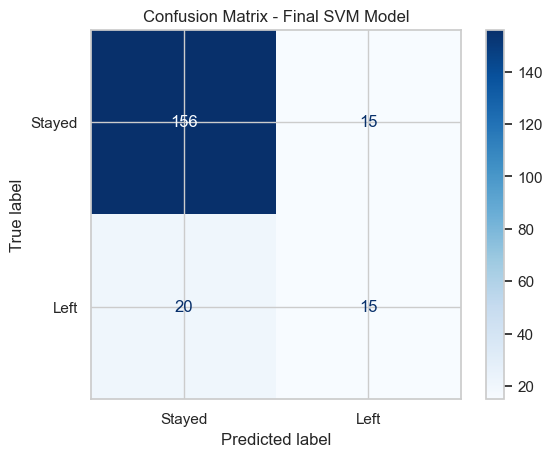

In [65]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("After SMOTE:", y_train_smote.value_counts())

scaler = StandardScaler()

# Fit scaler to SMOTE data
X_train_smote_scaled = scaler.fit_transform(X_train_smote)

# Apply scaler to validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Define SVM pipeline
svm_pipeline = Pipeline([
    ('svm', SVC(probability=True, random_state=42))
])

# Define hyperparameter grid
svm_param_grid = {
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__class_weight': [None, 'balanced']
}

# Grid search for best hyperparameters on SMOTE-balanced data
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV on SMOTE-scaled training data
grid_search_svm.fit(X_train_smote_scaled, y_train_smote)

# Display best parameters
print("Best SVM Parameters:", grid_search_svm.best_params_)
print("Best SVM CV ROC-AUC Score:", grid_search_svm.best_score_)

from sklearn.metrics import classification_report, roc_auc_score

# Predict on validation set
best_svm_model = grid_search_svm.best_estimator_
y_val_proba = best_svm_model.predict_proba(X_val_scaled)[:, 1]

# Adjust threshold if necessary
threshold = 0.3
y_val_pred_custom = (y_val_proba > threshold).astype(int)

# Print validation metrics
print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print(classification_report(y_val, y_val_pred_custom, target_names=['Stayed', 'Left']))

# Combine training and validation data for final training
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

# SMOTE again on combined data
X_final_smote, y_final_smote = smote.fit_resample(X_final, y_final)

# Scale final dataset
X_final_smote_scaled = scaler.fit_transform(X_final_smote)
X_test_scaled = scaler.transform(X_test)

# Train SVM using best hyperparameters from GridSearchCV
final_svm_model = SVC(
    C=grid_search_svm.best_params_['svm__C'],
    kernel=grid_search_svm.best_params_['svm__kernel'],
    class_weight=grid_search_svm.best_params_['svm__class_weight'],
    probability=True,
    random_state=42
)

final_svm_model.fit(X_final_smote_scaled, y_final_smote)

# Test predictions
y_test_proba = final_svm_model.predict_proba(X_test_scaled)[:, 1]

# Threshold adjustment (e.g., 0.3 to boost recall)
threshold = 0.3
y_test_pred_custom = (y_test_proba > threshold).astype(int)

# Test evaluation metrics
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print(classification_report(y_test, y_test_pred_custom, target_names=['Stayed', 'Left']))
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Final SVM Model")
plt.show()

***Model Comparison: Logistic Regression vs SVM***

Both models were trained using SMOTE to handle class imbalance. Logistic Regression achieved a strong ROC-AUC of 0.95 in cross-validation and had higher recall (57%) for identifying employees who left, though with lower precision (40%), meaning more false positives.

The SVM model had higher overall accuracy (83%) and balanced precision and recall (both 49%) for the “Left” class. Its test ROC-AUC was slightly lower at 0.78, but it made fewer incorrect predictions of leavers.

In short, Logistic Regression is better at catching more true leavers, while SVM offers more balanced and accurate predictions overall, with fewer false alarms.

**Final Model Chosen:** Logistic Regression


**3.3: Feature Importance**

Feature importance helps us understand which factors most influence employee attrition. This is crucial for HR teams to address potential issues and improve retention strategies.

🔍 Top 15 features influencing RCC acceptance:

                              Feature  Coefficient  Absolute_Coefficient
27       EducationField_Life Sciences    -1.829329              1.829329
25  Department_Research & Development    -1.825926              1.825926
29             EducationField_Medical    -1.796702              1.796702
39            JobRole_Sales Executive    -1.357973              1.357973
33            JobRole_Human Resources    -1.045657              1.045657
16                  TotalWorkingYears    -1.024753              1.024753
19                     YearsAtCompany     0.872090              0.872090
35                    JobRole_Manager    -0.870722              0.870722
30               EducationField_Other    -0.858218              0.858218
28           EducationField_Marketing    -0.852214              0.852214
31    EducationField_Technical Degree    -0.745603              0.745603
40       JobRole_Sales Representative    -0.741599              0.741599
43  

C:\Users\Tithi\AppData\Local\Temp\ipykernel_29312\2130278740.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15),


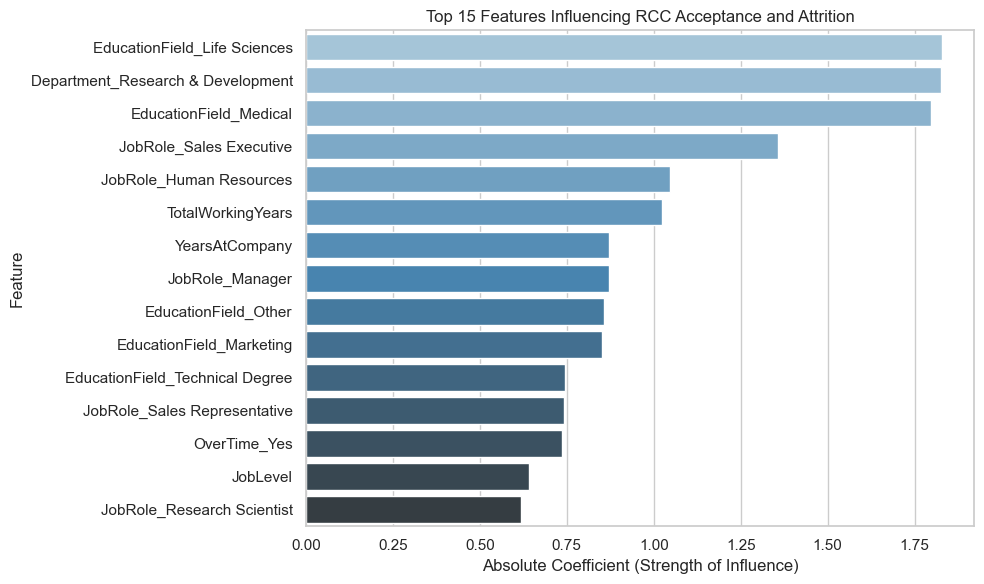

In [66]:
# Step 1: Extract feature names from your dataset
feature_names = X_train.columns

# Step 2: Extract the logistic regression coefficients from your final model
logreg_model = pipeline.named_steps['logreg']
coefficients = final_model.coef_[0]

# Step 3: Create a DataFrame to visualize clearly
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

# Step 4: Sort the features by absolute value (importance)
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

# Step 5: Display the top 15 most influential features
print("🔍 Top 15 features influencing RCC acceptance:\n")
print(feature_importance.head(15))

# Step 6: Visualization (Bar Plot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), 
            x='Absolute_Coefficient', 
            y='Feature', 
            palette='Blues_d')

plt.title('Top 15 Features Influencing RCC Acceptance and Attrition')
plt.xlabel('Absolute Coefficient (Strength of Influence)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

***What Drives Employees to Accept an RCC? (Logistic Regression Insights)***

The logistic regression model highlights key features influencing an employee’s decision to accept a Retention Compensation Contract (RCC). 

The top 15 features from our model offer valuable insights into the factors influencing an employee’s decision to accept a rupture conventionnelle collective (RCC).

Employees working in Research & Development or with backgrounds in Life Sciences and Medical fields are significantly less likely to accept an RCC, as indicated by their strong negative coefficients. This suggests a deeper attachment to their roles, specialized skill alignment, or limited external mobility.

Similarly, Sales Executives, Managers, and Human Resources staff are also less likely to leave, potentially due to leadership responsibilities or organizational influence.

On the other hand, employees with longer tenure at the company and those who work overtime are more likely to accept an RCC. This may reflect fatigue, burnout, or a desire for change after extended service.

Interestingly, education fields like Marketing or Other, and roles like Sales Representatives, show moderate influence toward leaving, perhaps reflecting transferable skills and external opportunities. Also, lower job levels and fewer total working years are associated with higher likelihood of exit, pointing to younger, less-established employees being more open to voluntary departure.

In short, less experienced, lower-level employees with generalist backgrounds and high workloads are more inclined to accept RCCs, while specialized, tenured, and leadership staff tend to stay.


____

### PART 2: Use your model on "employee_attrition_lyon.csv" to predict the likelihood that this employee will leave if offered an RCC. Create a csv-file “attrition_prediction.csv”, containing the likelihood of accepting the RCC as the only column. 

***Step 1: Data Exploration and Visualization***

In this section, we will load the dataset "employee_attrition_lyon.csv", perform initial exploration, and visualize the data to understand its characteristics.

In [67]:
# Load the dataset into a pandas DataFrame
df_lyon = pd.read_csv("employee_attrition_lyon.csv")

# Display the first 5 rows of the dataset to understand its structure
df_lyon.head()

# Get the number of rows and columns
print("Dataset Shape:", df_lyon.shape)

# Get information on data types and missing values
df_lyon.info()

# View basic descriptive statistics for numerical columns
df_lyon.describe()

Dataset Shape: (441, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       386 non-null    float64
 1   BusinessTravel            436 non-null    object 
 2   DailyRate                 427 non-null    float64
 3   Department                441 non-null    object 
 4   DistanceFromHome          387 non-null    float64
 5   Education                 441 non-null    int64  
 6   EducationField            441 non-null    object 
 7   EmployeeCount             441 non-null    int64  
 8   EmployeeNumber            441 non-null    int64  
 9   EnvironmentSatisfaction   441 non-null    int64  
 10  Gender                    441 non-null    object 
 11  HourlyRate                441 non-null    int64  
 12  JobInvolvement            441 non-null    int64  
 13  JobLevel                  441 non-null  

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,386.000000,427.000000,387.000000,441.000000,441.0,441.000000,441.000000,441.000000,441.000000,441.000000,...,441.000000,441.0,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000
mean,38.000000,800.960187,9.459948,2.961451,1.0,1026.027211,2.811791,64.049887,2.768707,2.111111,...,2.764172,80.0,0.727891,11.473923,2.839002,2.791383,7.160998,4.260771,2.346939,4.396825
std,8.832055,395.674732,8.123102,0.951488,0.0,592.604321,1.080171,19.889176,0.714156,1.078251,...,1.088654,0.0,0.793936,7.603819,1.303465,0.727398,6.264541,3.542922,3.471939,3.661705
min,18.000000,104.000000,1.000000,1.000000,1.0,14.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,466.000000,2.000000,2.000000,1.0,485.000000,2.000000,47.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,7.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,37.000000,796.000000,8.000000,3.000000,1.0,1024.000000,3.000000,63.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,44.000000,1142.500000,15.000000,4.000000,1.0,1557.000000,4.000000,81.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2065.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [68]:
# Check for missing values in each column
missing_values = df_lyon.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 Age                         55
BusinessTravel               5
DailyRate                   14
Department                   0
DistanceFromHome            54
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                3
MonthlyIncome                0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
TrainingTimesLastYear        0
WorkLifeBalance              0
YearsAtCompany               0
YearsIn

Numeric Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


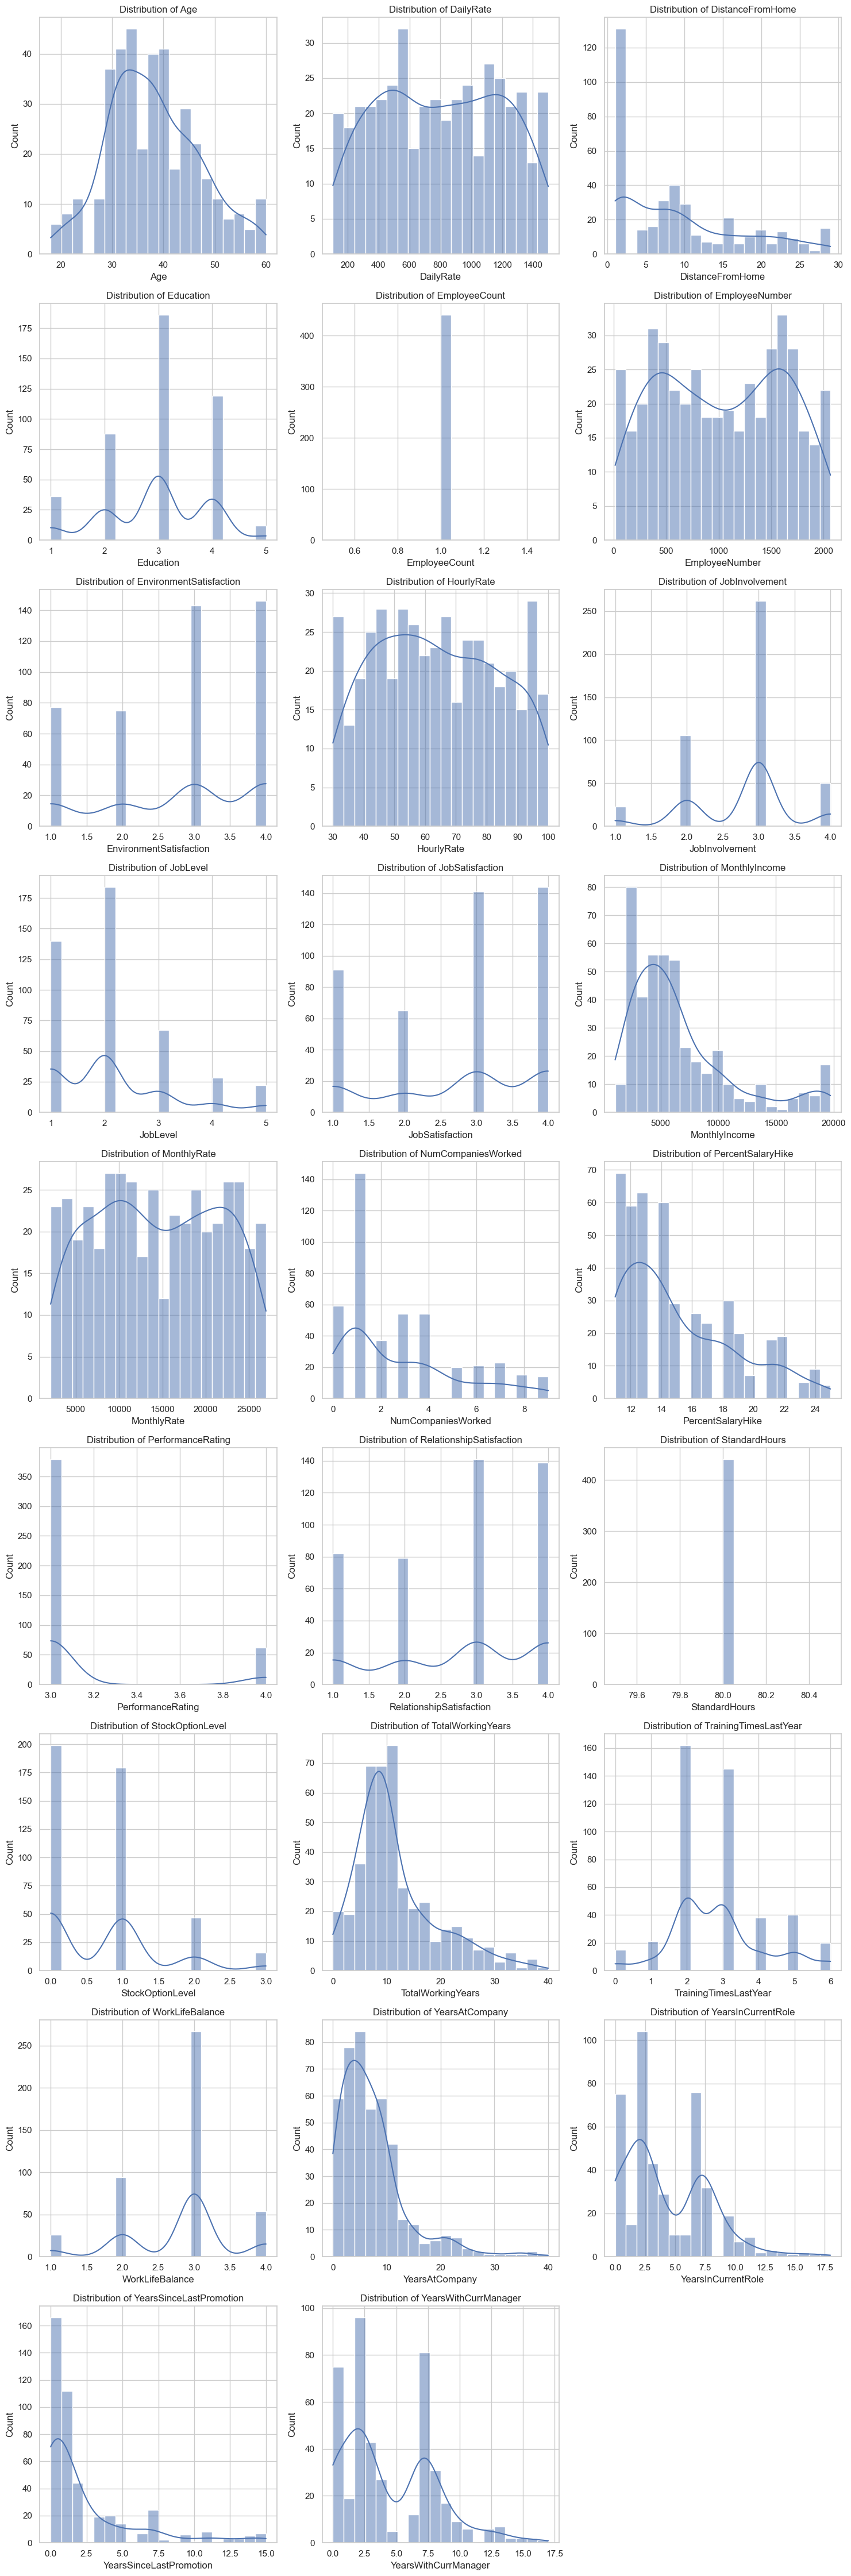

In [69]:
import numpy as np

# Plot histograms for all numerical columns

numeric_cols = df_lyon.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric Columns:", numeric_cols)

# Set up the matplotlib figure
num_cols = len(numeric_cols)
rows = (num_cols // 3) + (num_cols % 3 > 0)  # Calculate the number of rows needed
plt.figure(figsize=(15, 5 * rows))  # Adjust the figure size dynamically
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 3, i)  # Adjust the grid size dynamically
    sns.histplot(df_lyon[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Categorical Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


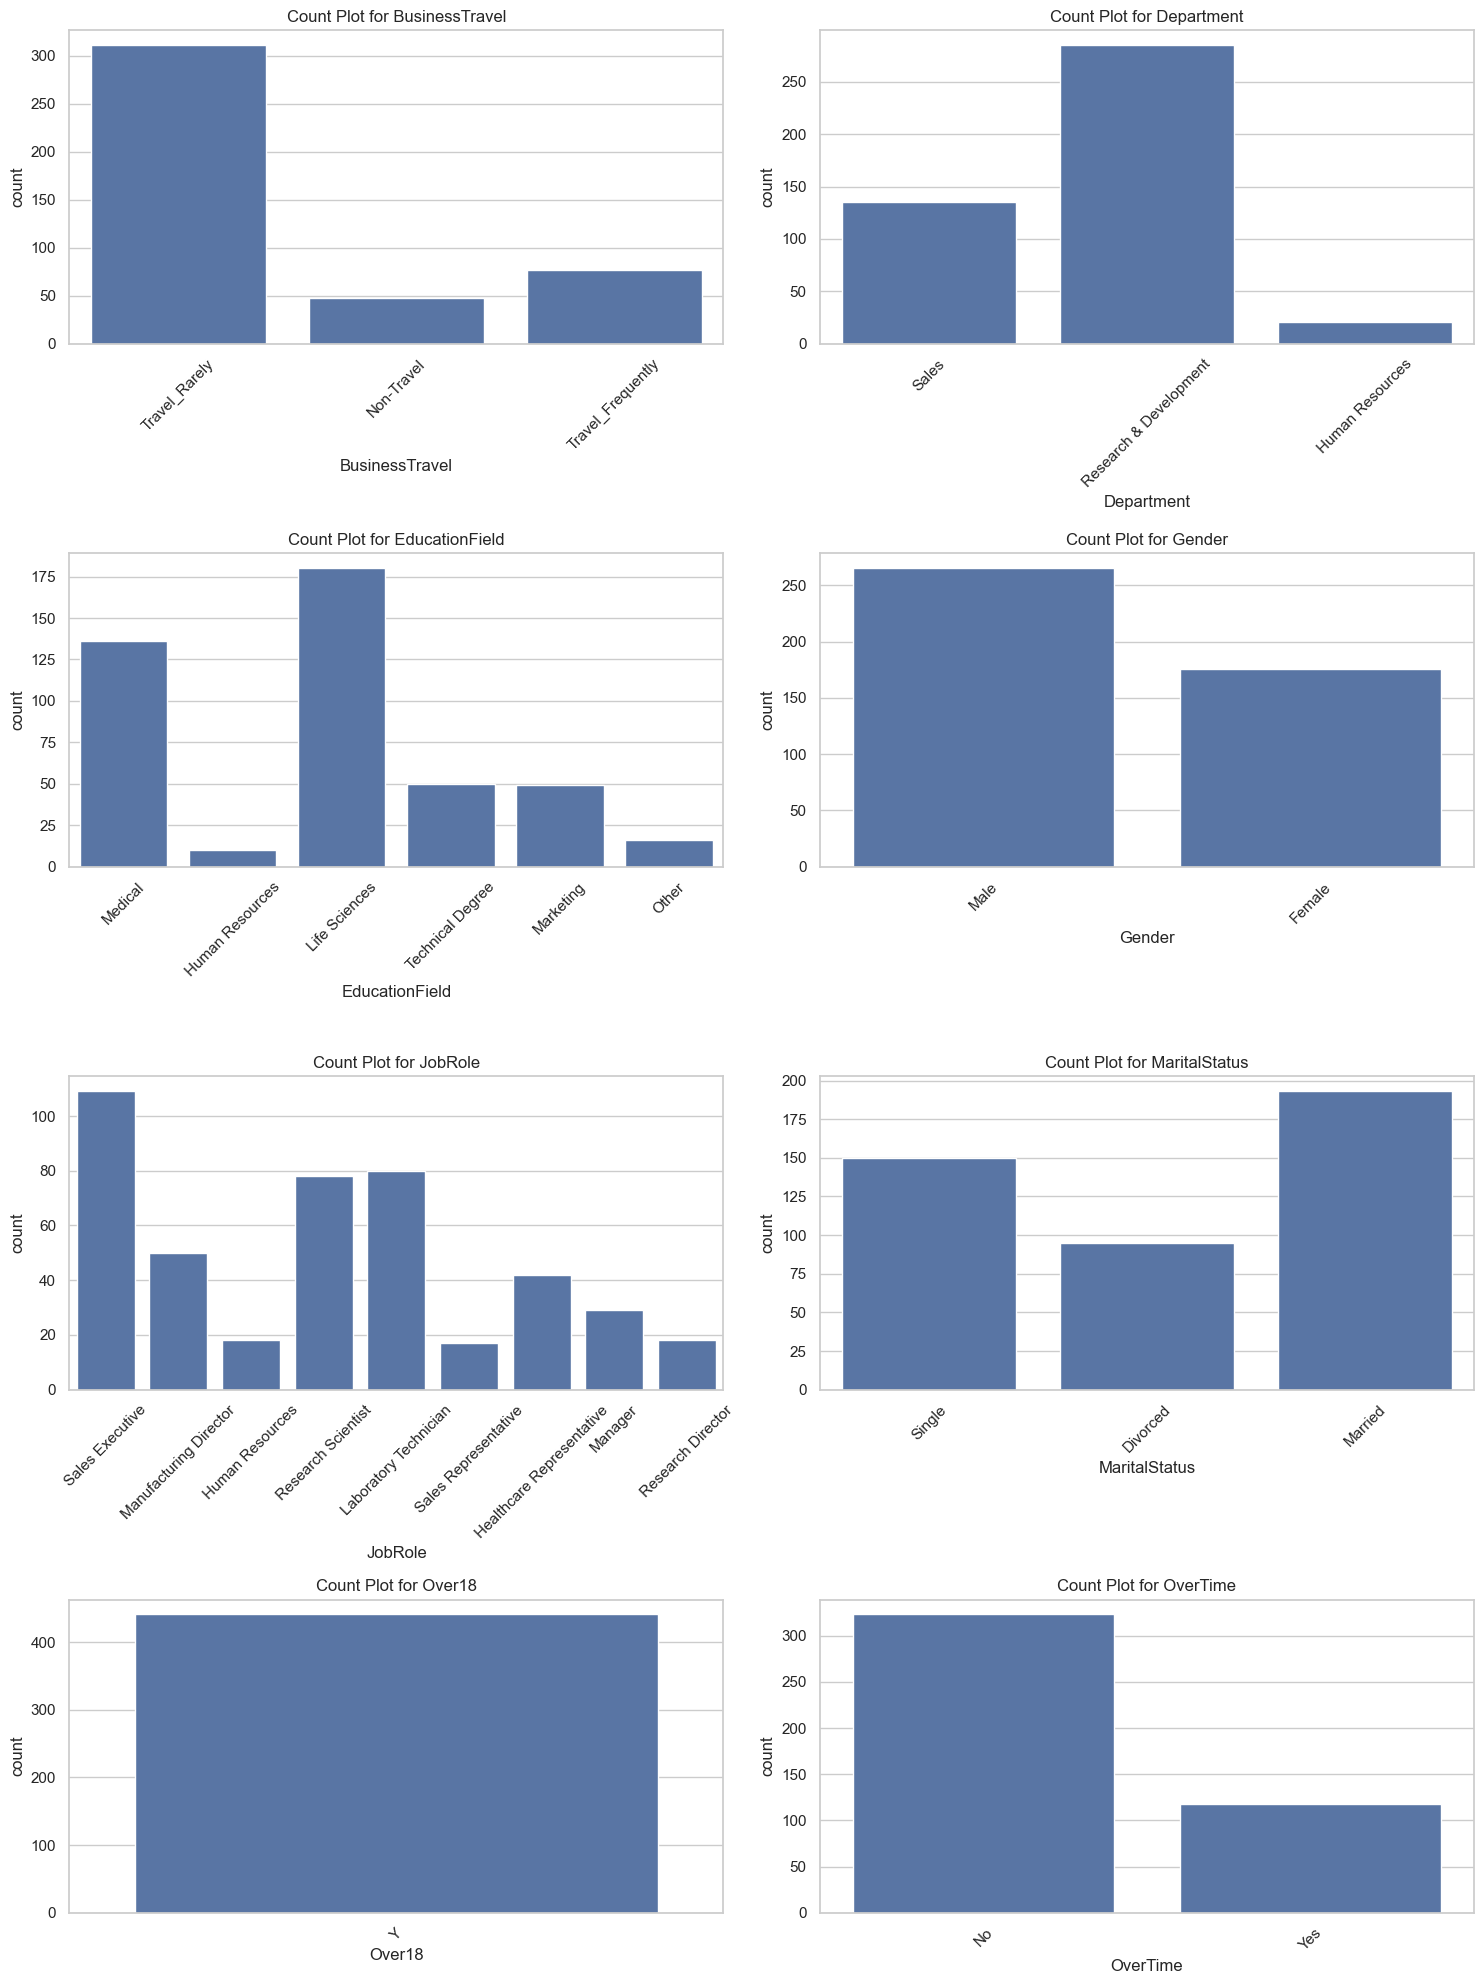

In [70]:
#Bar Charts for Categorical Data  
import math

# Get the list of categorical columns (assuming these are columns with data type 'object')
categorical_cols = df_lyon.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

# Set the number of columns for our grid layout (adjust as needed)
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

# Create a figure with the appropriate number of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop over each categorical column and create a countplot on the corresponding subplot
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df_lyon, ax=axes[i])
    axes[i].set_title(f"Count Plot for {col}")
    axes[i].tick_params(axis='x', rotation=45)

# If there are extra subplots (when the number of categorical variables is odd), remove them
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

***Data Exploration Summary — `employee_attrition_lyon.csv`***

**Data Quality & Missing Values**

A few features contain missing values:
- **Age** (55 missing)
- **DistanceFromHome** (54 missing)
- **DailyRate** (14 missing)
- **BusinessTravel** (5 missing)
- **MaritalStatus** (3 missing)

These should be imputed using the **same strategy** as used during training:
- **Numerical columns** → fill with **median**
- **Categorical columns** → fill with **mode**

**Key Takeaways**

- The Lyon dataset is generally clean and structurally consistent with the training data, making it **ready for model inference** after basic cleaning.
- Some features will need **preprocessing** (missing value imputation, encoding, dropping constants) to match the model-ready format used during training.
- Feature distributions indicate similar trends as seen in the training set — e.g., skewed tenure, diverse job roles, and varied satisfaction levels — which supports model generalization.

***Step 2: Data cleaning and preprocessing***

In this section, we will clean the dataset by removing unnecessary columns, handling missing values, and encoding categorical variables. We will also drop non-informative features and constant features. Finally, we will use the trained model to predict the likelihood of accepting an RCC for each employee in the Lyon dataset.

In [71]:
def preprocess_lyon(df_lyon):
    df_lyon = df_lyon.copy()

    # Fill missing values
    df_lyon['Age'].fillna(df_lyon['Age'].median(), inplace=True)
    df_lyon['DailyRate'].fillna(df_lyon['DailyRate'].median(), inplace=True)
    df_lyon['DistanceFromHome'].fillna(df_lyon['DistanceFromHome'].median(), inplace=True)
    df_lyon['BusinessTravel'].fillna(df_lyon['BusinessTravel'].mode()[0], inplace=True)
    df_lyon['MaritalStatus'].fillna(df_lyon['MaritalStatus'].mode()[0], inplace=True)

    # Drop non-informative columns
    df_lyon.drop(columns=[
        'EmployeeNumber', 'EmployeeCount', 'Over18',
        'StandardHours'
    ], inplace=True)

    # One-hot encode
    df_lyon_encoded = pd.get_dummies(df_lyon, drop_first=True)
    # Since, after one-hot encoding, the new columns are of type bool, we need to convert them to integers (0 and 1) for better compatibility with machine learning algorithms.
    # Convert boolean columns to integers (0 and 1)
    df_lyon_encoded = df_lyon_encoded.astype(int)

    return df_lyon_encoded

In [72]:
X_lyon = preprocess_lyon(df_lyon)

# Print the shape of the processed DataFrame
print("Processed Lyon DataFrame Shape:", X_lyon.shape)
# Print the first few rows of the processed DataFrame
print("Processed Lyon DataFrame Head:\n", X_lyon.head())
# Check the data types of the columns to ensure they are as expected
print("Data Types of Columns:\n", X_lyon.dtypes)

# Create a csv file of the processed DataFrame
X_lyon.to_csv("processed_employee_attrition_lyon.csv", index=False)
print("Processed DataFrame saved as 'processed_employee_attrition_lyon.csv'")

# Check for missing values after encoding
missing_values_encoded = X_lyon.isnull().sum()
print("Missing Values After Encoding:\n", missing_values_encoded[missing_values_encoded > 0])

Processed Lyon DataFrame Shape: (441, 44)
Processed Lyon DataFrame Head:
    Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0   37        866                 8          3                        4   
1   53       1084                13          2                        4   
2   24        240                22          1                        4   
3   45       1339                 7          3                        2   
4   36       1396                 8          2                        4   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0          84               3         2                1           8463  ...   
1          57               4         2                1           4450  ...   
2          58               1         1                3           1555  ...   
3          59               3         3                1           9724  ...   
4          62               3         2                2           5914  ..

C:\Users\Tithi\AppData\Local\Temp\ipykernel_29312\1201655039.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_lyon['Age'].fillna(df_lyon['Age'].median(), inplace=True)
C:\Users\Tithi\AppData\Local\Temp\ipykernel_29312\1201655039.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [73]:
# Align columns to match training data
X_lyon_aligned = X_lyon.reindex(columns=X.columns, fill_value=0)

# Scale the new data using the same scaler
X_lyon_scaled = scaler.transform(X_lyon_aligned)


***Step 3: Predicting Attrition Likelihood***

In this section, we will use the trained model to predict the likelihood of accepting an RCC for each employee in the Lyon dataset. We will create a CSV file "attrition_prediction.csv" containing the likelihood of accepting the RCC as the only column.

In [74]:
# Predict probabilities for class 1 (Attrition = Yes)
y_lyon_proba = final_model.predict_proba(X_lyon_scaled)[:, 1]

# Save to CSV
import pandas as pd
pd.DataFrame(y_lyon_proba, columns=["Attrition_Probability"]).to_csv("attrition_prediction.csv", index=False)


In [75]:
# Check shape
print("Predicted probabilities:", y_lyon_proba.shape)

# Quick summary
print(pd.Series(y_lyon_proba).describe())


Predicted probabilities: (441,)
count    441.000000
mean       0.196933
std        0.242474
min        0.000014
25%        0.021826
50%        0.085885
75%        0.294291
max        0.981426
dtype: float64


____

In [76]:
# Re-import necessary libraries after code execution state reset
import pandas as pd

# Re-load the necessary CSV files
lyon_df = pd.read_csv("employee_attrition_lyon.csv")
attrition_pred = pd.read_csv("attrition_prediction.csv")

# Merge attrition predictions
lyon_df["Attrition_Probability"] = attrition_pred["Attrition_Probability"]

# Fill missing values
for col in ['Age', 'DailyRate', 'DistanceFromHome']:
    lyon_df[col].fillna(lyon_df[col].median(), inplace=True)
for col in ['BusinessTravel', 'MaritalStatus']:
    lyon_df[col].fillna(lyon_df[col].mode()[0], inplace=True)

# Strategic group design: Department + OverTime + Tenure Group + Salary Group
lyon_df["Tenure_Group"] = pd.cut(lyon_df["YearsAtCompany"],
                                 bins=[-1, 2, 6, float('inf')],
                                 labels=["Newcomer", "Mid-Tenure", "Long-Timer"])
lyon_df["Salary_Group"] = pd.qcut(lyon_df["MonthlyIncome"], q=3, labels=["Low", "Medium", "High"])

lyon_df["Group_ID"] = (
    lyon_df["Department"] + "_" +
    lyon_df["OverTime"].astype(str) + "_" +
    lyon_df["Tenure_Group"].astype(str) + "_" +
    lyon_df["Salary_Group"].astype(str)
)

# Group-level calculations
grouped = lyon_df.groupby(["Group_ID", "Department"]).agg({
    "Attrition_Probability": "mean",
    "MonthlyIncome": ["sum", "mean"],
    "EmployeeNumber": "count"
}).reset_index()

grouped.columns = ["Group_ID", "Department", "Avg_Attr_Prob", "Total_Salary", "Avg_Salary", "Num_Employees"]

# Expected Leavers, Salary Saved, Severance Cost
grouped["Expected_Leavers"] = grouped["Avg_Attr_Prob"] * grouped["Num_Employees"]
grouped["Expected_Salary_Saved"] = grouped["Avg_Attr_Prob"] * grouped["Total_Salary"]
grouped["Severance_Cost"] = grouped["Expected_Leavers"] * grouped["Avg_Salary"] * 1.5

# Calculate total department size for max 20% rule
dept_sizes = lyon_df["Department"].value_counts().to_dict()

# Aggregate for Solver summary
solver_summary = {
    "Total_Expected_Exit": grouped["Expected_Leavers"].sum(),
    "Total_Salary_Saved": grouped["Expected_Salary_Saved"].sum(),
    "Total_Severance_Cost": grouped["Severance_Cost"].sum(),
    "Max_Exit_HR": 0.2 * dept_sizes.get("Human Resources", 0),
    "Max_Exit_Sales": 0.2 * dept_sizes.get("Sales", 0),
    "Max_Exit_RD": 0.2 * dept_sizes.get("Research & Development", 0)
}

summary_df = pd.DataFrame.from_dict(solver_summary, orient="index", columns=["Value"])


# This will be exported to Excel and Solver will pick binary variables to minimize Severance_Cost
# Save the grouped DataFrame to a CSV file for further use
grouped.to_excel("task_4_solver_input_table.xlsx", index=False)
print("Task 4 Solver Input Table saved as 'task_4_solver_input_table.xlsx'")


Task 4 Solver Input Table saved as 'task_4_solver_input_table.xlsx'


C:\Users\Tithi\AppData\Local\Temp\ipykernel_29312\239336000.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lyon_df[col].fillna(lyon_df[col].median(), inplace=True)
C:\Users\Tithi\AppData\Local\Temp\ipykernel_29312\239336000.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


### PART 3: Recall that RCCs cannot be offered to individuals directly, but only to “objectively” defined groups of employees. Discuss how you could define such groups, and what the pros and cons are of smaller or larger group sizes. Moreover, discuss how you would measure whether your group definition is non-discriminatory.

In [77]:
%pip install xlsxwriter

Note: you may need to restart the kernel to use updated packages.


In [78]:
import pandas as pd
import numpy as np
import xlsxwriter

# Load datasets
lyon_df = pd.read_csv('processed_employee_attrition_lyon.csv')
attrition_probs = pd.read_csv('attrition_prediction.csv')

# Combine datasets
df = lyon_df.copy()
df['Attrition_Probability'] = attrition_probs['Attrition_Probability']

# Add employee ID if not present
if 'EmployeeID' not in df.columns:
    df['EmployeeID'] = range(1, len(df) + 1)

# Create a Department_Human Resources column - employees with HR job role
# First check if they're not already in another department
df['Department_Human Resources'] = 0  # Initialize with 0

# Employees with Human Resources job role who are not in Sales or R&D are in the HR department
df.loc[(df['JobRole_Human Resources'] == 1) & 
       (df['Department_Research & Development'] != 1) & 
       (df['Department_Sales'] != 1), 'Department_Human Resources'] = 1

# Ensure OverTime column is properly named (it appears to be OverTime_Yes in the dataset)
# This is needed because our grouping functions use 'OverTime' rather than 'OverTime_Yes'
df['OverTime'] = df['OverTime_Yes']

# Define focused grouping strategy based on top predictors
# From feature importance chart, focus on top 5-6 most important factors:
# 1. OverTime
# 2. NumCompaniesWorked
# 3. JobRole_Healthcare Representative
# 4. YearsInCurrentRole
# 5. EnvironmentSatisfaction
# 6. TotalWorkingYears

# 1. Create primary group based on OverTime and NumCompaniesWorked (top 2 factors)
def create_primary_group(row):
    if row['OverTime'] == 1:  # Working overtime
        if row['NumCompaniesWorked'] >= 4:
            return "High-Mobility Overtime"
        else:
            return "Low-Mobility Overtime"
    else:  # Not working overtime
        if row['NumCompaniesWorked'] >= 4:
            return "High-Mobility Standard"
        else:
            return "Low-Mobility Standard"

# 2. Create secondary group based on department and tenure
def create_department_tenure_group(row):
    # Department identification
    if row['Department_Human Resources'] == 1:
        dept = "HR"
    elif row['Department_Research & Development'] == 1:
        dept = "R&D"
    elif row['Department_Sales'] == 1:
        dept = "Sales"
    else:
        # If they have HR job role but are in another department
        if row['JobRole_Human Resources'] == 1:
            dept = "HR"
        else:
            # As a fallback, assign to "Other" - though from our analysis
            # there should be very few (3) employees in this category
            dept = "Other"
    
    # Tenure classification based on YearsInCurrentRole and TotalWorkingYears
    # More weight on YearsInCurrentRole as it's more important in the chart
    if row['YearsInCurrentRole'] <= 2:
        tenure = "New Role"
    elif row['YearsInCurrentRole'] <= 5:
        tenure = "Established Role"
    else:
        tenure = "Veteran Role"
    
    return f"{dept} {tenure}"

# 3. Create satisfaction group (using EnvironmentSatisfaction which is in top 5)
def create_satisfaction_group(row):
    if row['EnvironmentSatisfaction'] <= 2:
        return "Low Satisfaction"
    else:
        return "High Satisfaction"

# Apply the classifications
df['Primary_Group'] = df.apply(create_primary_group, axis=1)
df['Department_Tenure'] = df.apply(create_department_tenure_group, axis=1)
df['Satisfaction'] = df.apply(create_satisfaction_group, axis=1)

# Create strategic group combinations - start with primary x department
df['Strategic_Group'] = df['Primary_Group'] + " | " + df['Department_Tenure']

# Check how many groups this creates
initial_group_count = df['Strategic_Group'].nunique()
print(f"Initial group count: {initial_group_count}")

# If we have too many groups, simplify further
if initial_group_count > 15:
    # Simplify by combining some department tenure categories
    def simplify_dept_tenure(dept_tenure):
        dept = dept_tenure.split()[0]
        tenure = " ".join(dept_tenure.split()[1:])
        
        # For HR, don't distinguish by tenure (typically smaller department)
        if dept == "HR":
            return "HR"
        # For others, keep some tenure distinction
        else:
            if "New" in tenure:
                return f"{dept} New"
            else:
                return f"{dept} Established"
    
    # Apply simplification
    df['Department_Tenure'] = df['Department_Tenure'].apply(simplify_dept_tenure)
    df['Strategic_Group'] = df['Primary_Group'] + " | " + df['Department_Tenure']
    
    # Check group count again
    simplified_group_count = df['Strategic_Group'].nunique()
    print(f"Simplified group count: {simplified_group_count}")
    
    # If still too many, further simplify
    if simplified_group_count > 15:
        # Only use satisfaction for overtime workers (higher attrition risk)
        df['Strategic_Group'] = df.apply(
            lambda row: (row['Primary_Group'] + " | " + row['Department_Tenure'] + 
                         (" | " + row['Satisfaction'] if "Overtime" in row['Primary_Group'] else "")),
            axis=1
        )
        
        # Final group count
        final_group_count = df['Strategic_Group'].nunique()
        print(f"Final group count: {final_group_count}")

# Count employees in each strategic group
group_counts = df['Strategic_Group'].value_counts().reset_index()
group_counts.columns = ['Strategic_Group', 'Employee_Count']

# Check if any groups are too small (< 5 employees)
small_groups = group_counts[group_counts['Employee_Count'] < 5]
if not small_groups.empty:
    print(f"Found {len(small_groups)} small groups with < 5 employees")
    
    # Merge small groups into larger ones with similar characteristics
    for small_group in small_groups['Strategic_Group']:
        # Extract primary and department components
        components = small_group.split(' | ')
        primary = components[0]
        department = components[1].split()[0]  # Get just the department name
        
        # Find a similar larger group to merge with
        similar_groups = group_counts[
            (group_counts['Strategic_Group'].str.contains(primary)) & 
            (group_counts['Strategic_Group'].str.contains(department)) &
            (group_counts['Employee_Count'] >= 5)
        ]
        
        if not similar_groups.empty:
            # Merge with the largest similar group
            target_group = similar_groups.iloc[0]['Strategic_Group']
            df.loc[df['Strategic_Group'] == small_group, 'Strategic_Group'] = target_group
            print(f"Merged '{small_group}' into '{target_group}'")
        else:
            # If no similar group, merge with the largest group that shares the primary component
            similar_primary = group_counts[
                (group_counts['Strategic_Group'].str.contains(primary)) &
                (group_counts['Employee_Count'] >= 5)
            ]
            
            if not similar_primary.empty:
                target_group = similar_primary.iloc[0]['Strategic_Group']
                df.loc[df['Strategic_Group'] == small_group, 'Strategic_Group'] = target_group
                print(f"Merged '{small_group}' into '{target_group}' based on primary component")
            else:
                # Last resort: merge with the largest group
                target_group = group_counts.iloc[0]['Strategic_Group']
                df.loc[df['Strategic_Group'] == small_group, 'Strategic_Group'] = target_group
                print(f"Merged '{small_group}' into largest group '{target_group}'")

# Assign group IDs for easier reference
final_groups = sorted(df['Strategic_Group'].unique())
group_mapping = {group: f"G{i+1}" for i, group in enumerate(final_groups)}
df['Strategic_Group_ID'] = df['Strategic_Group'].map(group_mapping)

# Create the Group Summary Table
group_summary = df.groupby('Strategic_Group_ID').agg(
    Group_Description=('Strategic_Group', 'first'),
    Number_of_Employees=('Strategic_Group', 'count'),
    Avg_Attrition_Probability=('Attrition_Probability', 'mean'),
    Avg_Monthly_Income=('MonthlyIncome', 'mean'),
    Total_Monthly_Income=('MonthlyIncome', 'sum')
).reset_index()

# Calculate expected leavers and financial impact
group_summary['Expected_Leavers'] = group_summary['Number_of_Employees'] * group_summary['Avg_Attrition_Probability']
group_summary['Expected_Annual_Savings'] = group_summary['Expected_Leavers'] * group_summary['Avg_Monthly_Income'] * 12

# Calculate department composition percentages
for dept in ['Department_Human Resources', 'Department_Research & Development', 'Department_Sales']:
    dept_counts = df.groupby('Strategic_Group_ID')[dept].sum().reset_index()
    dept_name = dept.replace('Department_', '')
    group_summary[f'%_{dept_name}'] = 100 * dept_counts[dept] / group_summary['Number_of_Employees']

# Add placeholder for RCC Offered (will be your decision variable)
group_summary['RCC_Offered'] = 0

# Sort by expected savings (descending) to easily identify high-value groups
group_summary = group_summary.sort_values('Expected_Annual_Savings', ascending=False)

# Add an ROI metric (savings per cost)
# Assuming severance cost is 3 months of salary for those who accept
severance_multiplier = 3
group_summary['Expected_RCC_Cost'] = group_summary['Expected_Leavers'] * group_summary['Avg_Monthly_Income'] * severance_multiplier
group_summary['ROI'] = group_summary['Expected_Annual_Savings'] / group_summary['Expected_RCC_Cost']

# Save the results to CSV files
df[['EmployeeID', 'Primary_Group', 'Department_Tenure', 'Satisfaction', 
    'Strategic_Group', 'Strategic_Group_ID', 'Attrition_Probability']].to_csv('focused_employee_grouping.csv', index=False)

group_summary.to_csv('focused_group_summary.csv', index=False)

# Create Excel file for optimization
with pd.ExcelWriter('optimization_model.xlsx', engine='xlsxwriter') as writer:
    # Write main group data
    group_summary.to_excel(writer, sheet_name='Groups', index=False)
    
    # Add summary of departments
    # For HR department, count employees with HR job role that aren't in other departments
    hr_count = df.loc[(df['JobRole_Human Resources'] == 1) & 
                       (df['Department_Research & Development'] != 1) & 
                       (df['Department_Sales'] != 1)].shape[0]
    
    dept_summary = pd.DataFrame({
        'Department': ['Human Resources', 'Research & Development', 'Sales', 'Other', 'Total'],
        'Current_Count': [
            hr_count,
            df['Department_Research & Development'].sum(),
            df['Department_Sales'].sum(),
            len(df) - hr_count - df['Department_Research & Development'].sum() - df['Department_Sales'].sum(),
            len(df)
        ]
    })
    dept_summary.to_excel(writer, sheet_name='Departments', index=False)
    
    # Add constraints sheet
    constraints = pd.DataFrame({
        'Constraint': [
            'Total Leavers ≥ 40',
            'Total Salary Saved ≥ €3,000,000',
            'HR Retention Ratio ≤ 0.80',
            'R&D Retention Ratio ≤ 0.80',
            'Sales Retention Ratio ≤ 0.80'
        ],
        'Description': [
            'At least 40 employees must leave',
            'At least €3 million in annual salary savings',
            'No more than 80% of HR employees can be retained',
            'No more than 80% of R&D employees can be retained',
            'No more than 80% of Sales employees can be retained'
        ]
    })
    constraints.to_excel(writer, sheet_name='Constraints', index=False)

# Print summary information and analysis
print("\n=== FINAL GROUP SUMMARY ===")
print(f"Total number of strategic groups: {len(group_summary)}")
print(f"Total number of employees: {len(df)}")

print("\nGroup sizes:")
size_info = group_summary[['Strategic_Group_ID', 'Group_Description', 'Number_of_Employees']].sort_values('Number_of_Employees', ascending=False)
print(size_info)

print("\nGroups by attrition probability:")
attrition_info = group_summary[['Strategic_Group_ID', 'Group_Description', 'Avg_Attrition_Probability', 'Expected_Leavers']].sort_values('Avg_Attrition_Probability', ascending=False)
print(attrition_info)

print("\nGroups by ROI (Annual Savings / RCC Cost):")
roi_info = group_summary[['Strategic_Group_ID', 'Group_Description', 'ROI', 'Expected_Annual_Savings', 'Expected_RCC_Cost']].sort_values('ROI', ascending=False)
print(roi_info)

print("\nDepartment composition by group:")
for idx, row in group_summary.iterrows():
    print(f"{row['Strategic_Group_ID']} ({row['Group_Description']}): HR {row['%_Human Resources']:.1f}%, R&D {row['%_Research & Development']:.1f}%, Sales {row['%_Sales']:.1f}%")

# Calculate totals for optimization baseline
total_employees = len(df)

# For HR department, count employees with HR job role that aren't in other departments
hr_employees = df.loc[(df['JobRole_Human Resources'] == 1) & 
                       (df['Department_Research & Development'] != 1) & 
                       (df['Department_Sales'] != 1)].shape[0]

rd_employees = df['Department_Research & Development'].sum()
sales_employees = df['Department_Sales'].sum()
other_employees = total_employees - hr_employees - rd_employees - sales_employees

total_expected_leavers = group_summary['Expected_Leavers'].sum()
total_expected_savings = group_summary['Expected_Annual_Savings'].sum()
total_expected_cost = group_summary['Expected_RCC_Cost'].sum()

print(f"\nTotal employees: {total_employees}")
print(f"Department distribution: HR {hr_employees} ({hr_employees/total_employees*100:.1f}%), " + 
      f"R&D {rd_employees} ({rd_employees/total_employees*100:.1f}%), " + 
      f"Sales {sales_employees} ({sales_employees/total_employees*100:.1f}%), " +
      f"Other {other_employees} ({other_employees/total_employees*100:.1f}%)")
print(f"If RCCs were offered to ALL groups:")
print(f"- Expected leavers: {total_expected_leavers:.1f}")
print(f"- Expected annual savings: €{total_expected_savings:,.2f}")
print(f"- Expected RCC cost: €{total_expected_cost:,.2f}")
print(f"- Overall ROI: {total_expected_savings/total_expected_cost:.2f}")

# Check if all constraints could theoretically be met
min_leavers_met = total_expected_leavers >= 40
min_savings_met = total_expected_savings >= 3000000

# Handle potential division by zero if there are no employees in a department
max_hr_retention = 0 if hr_employees == 0 else (hr_employees - (group_summary['Expected_Leavers'] * group_summary['%_Human Resources'] / 100).sum()) / hr_employees
max_rd_retention = 0 if rd_employees == 0 else (rd_employees - (group_summary['Expected_Leavers'] * group_summary['%_Research & Development'] / 100).sum()) / rd_employees
max_sales_retention = 0 if sales_employees == 0 else (sales_employees - (group_summary['Expected_Leavers'] * group_summary['%_Sales'] / 100).sum()) / sales_employees

print(f"\nConstraint check if ALL groups were offered RCCs:")
print(f"- Minimum 40 leavers: {'Met' if min_leavers_met else 'Not Met'} ({total_expected_leavers:.1f} expected)")
print(f"- Minimum €3M savings: {'Met' if min_savings_met else 'Not Met'} (€{total_expected_savings:,.2f} expected)")
print(f"- Maximum 80% HR retention: {'Met' if max_hr_retention <= 0.8 else 'Not Met'} ({max_hr_retention*100:.1f}% expected)")
print(f"- Maximum 80% R&D retention: {'Met' if max_rd_retention <= 0.8 else 'Not Met'} ({max_rd_retention*100:.1f}% expected)")
print(f"- Maximum 80% Sales retention: {'Met' if max_sales_retention <= 0.8 else 'Not Met'} ({max_sales_retention*100:.1f}% expected)")

Initial group count: 36
Simplified group count: 22
Final group count: 32
Found 12 small groups with < 5 employees
Merged 'High-Mobility Overtime | R&D New | Low Satisfaction' into 'High-Mobility Overtime | R&D New | High Satisfaction'
Merged 'High-Mobility Overtime | Sales New | Low Satisfaction' into 'High-Mobility Overtime | Sales New | High Satisfaction'
Merged 'High-Mobility Overtime | Sales Established | Low Satisfaction' into 'High-Mobility Overtime | Sales New | High Satisfaction'
Merged 'High-Mobility Overtime | R&D Established | Low Satisfaction' into 'High-Mobility Overtime | R&D New | High Satisfaction'
Merged 'Low-Mobility Standard | Other Established' into 'Low-Mobility Standard | R&D Established' based on primary component
Merged 'Low-Mobility Overtime | Sales New | Low Satisfaction' into 'Low-Mobility Overtime | Sales Established | High Satisfaction'
Merged 'Low-Mobility Overtime | Other Established | High Satisfaction' into 'Low-Mobility Overtime | R&D Established | Hig